In [1]:
import sys
#from src.E7_debug import E7 as E7_ricardo
from src.E7 import E7 as E7_ricardo
from src.E7_Amir import E7 as E7_amir
#from src.E7 import E7 as E7_original
from src.E8 import E8
from src.E9 import E9
from src.E10 import E10
import numpy as np
import time
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

def do_cov_sub_plot(ax, normalize, title, ax_index, C_order, ell_range, ell_p_range):
        
        l_min = ell_range[0]
        l_max = ell_range[1]
        lp_min = ell_p_range[0]
        lp_max = ell_p_range[1]
        C_order = np.where(np.abs(C_order) < 1e-12, 1e-12, np.abs(C_order))

        ell_to_s_map = np.array([l * (l+1) - l - l_min**2  for l in range(l_min, l_max+1)])
        ellp_to_s_map = np.array([l * (l+1) - l - lp_min**2  for l in range(lp_min, lp_max+1)])

        axim = ax.imshow(C_order.T, cmap='inferno', norm=LogNorm(), origin='lower',  interpolation = 'nearest')


        if l_max-l_min > 20:
            jump = np.array([5, 10, 15, 20])-2
            ax.set_xticks(ell_to_s_map[jump]- 0.5)
            ax.set_xticklabels(np.arange(l_min, l_max+1)[jump])
        else:
            ax.set_xticks(ell_to_s_map-0.5)
            ax.set_xticklabels(np.arange(l_min, l_max+1))

        if lp_max-lp_min > 20:
            jump = np.array([5, 10, 15, 20])-2
            ax.set_yticks(ellp_to_s_map[jump]- 0.5)
            ax.set_yticklabels(np.arange(lp_min, lp_max+1)[jump])
        else:
            ax.set_yticks(ellp_to_s_map-0.5)
            ax.set_yticklabels(np.arange(lp_min, lp_max+1))
        
        if lp_max > 50 or l_max > 50:
            ax.set_title(str(ax_index+5), weight='bold', fontsize='20')
        else:
            #ax.set_title(str(ax_index+1), weight='bold', fontsize='20')
            ax.set_title(title, weight='bold', fontsize='20')
            
        
        if ax_index == 3 or ax_index == 2:
            ax.set_xlabel(r"$\ell $")
        if ax_index == 0 or ax_index == 2: 
            ax.set_xlabel(r"$\ell $") 
            ax.set_ylabel(r"$\ell'$")
        if normalize:
            axim.set_clim(1e-8, 1e0)
        else:
            axim.set_clim(1e-14, 1e2)

        
        return axim


# Set parameter file
#import parameter_files.default as parameter_file
def run_topology_ricardo(topology, LAx, LAy, L1y = 0.1, L2x = 0.1, L2z = 0.1, l_max = 10, l_min = 2, x0 = np.array([0.0, 0.0, 0.0]), l_range= np.array([[2,2]]), lp_range= np.array([[2,2]])):
  
  if topology == 'E7' or 'E9' :
    import parameter_files.default_E7 as parameter_file

    param = parameter_file.parameter
    param['topology'] = topology
    param['LAx'] = LAx
    param['LAy'] = LAy
    param['L1y'] = L1y
    param['L2x'] = L2x
    param['L2z'] = L2z

  param['l_max'] = l_max
  param['l_min'] = l_min
  param['node'] = 1
  param['x0'] = x0

  if param['topology'] == 'E7':
    a = E7_ricardo(param=param, make_run_folder=True)
  else:
    exit()

  c_ell = a.calculate_c_lmlpmp(
    plot_param={
      'l_ranges':l_range,
      'lp_ranges': lp_range,
    }
  )
 
  return c_ell

def run_topology_amir(topology, LAx, LAy, L1y = 0.1, L2x = 0.1, L2z = 0.1, l_max = 10, l_min = 2, x0 = np.array([0.0, 0.0, 0.0]), l_range= np.array([[2,2]]), lp_range= np.array([[2,2]])):
  
  if topology == 'E7' or 'E9' :
    import parameter_files.default_E7 as parameter_file

    param = parameter_file.parameter
    param['topology'] = topology
    param['LAx'] = LAx
    param['LAy'] = LAy
    param['L1y'] = L1y
    param['L2x'] = L2x
    param['L2z'] = L2z

  param['l_max'] = l_max
  param['l_min'] = l_min
  param['node'] = 1
  param['x0'] = x0

  if param['topology'] == 'E7':
    a = E7_amir(param=param, make_run_folder=True)
  else:
    exit()

  c_ell = a.calculate_c_lmlpmp(
    plot_param={
      'l_ranges':l_range,
      'lp_ranges': lp_range,
    }
  )
 
  return c_ell




In [1]:
1.2/2

0.6

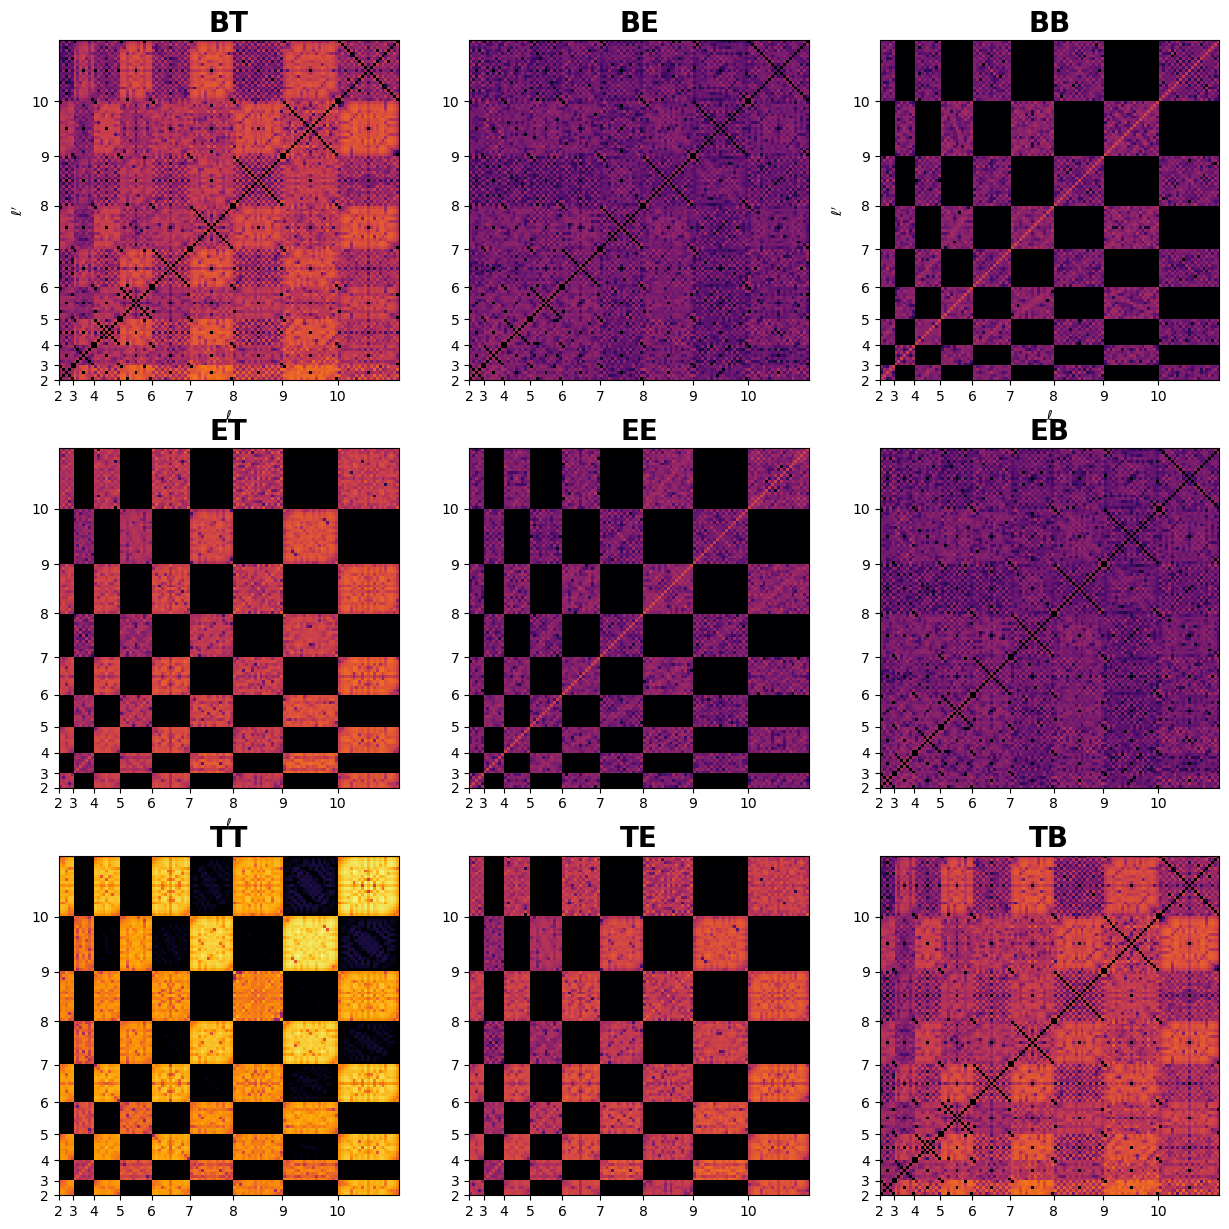

In [ ]:
fig, ax = plt.subplots(3,3, figsize=(15,15))
do_cov_sub_plot(ax[0,0], normalize=True, title = 'BT',  ax_index=0, C_order=c_ell_untilted[5], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[0,1], normalize=True, title = 'BE', ax_index=1, C_order=c_ell_untilted[4], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[0,2], normalize=True, title = 'BB', ax_index=2, C_order=c_ell_untilted[2], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[1,0], normalize=True, title = 'ET', ax_index=3, C_order=c_ell_untilted[3], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[1,1], normalize=True, title = 'EE', ax_index=4, C_order=c_ell_untilted[1], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[1,2], normalize=True, title = 'EB', ax_index=5, C_order=c_ell_untilted[4], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[2,0], normalize=True, title = 'TT', ax_index=6, C_order=c_ell_untilted[0], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[2,1], normalize=True, title = 'TE', ax_index=7, C_order=c_ell_untilted[3], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[2,2], normalize=True, title = 'TB', ax_index=8, C_order=c_ell_untilted[5], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))

In [24]:

l_max = 5
#L_circle = 0.73321

c_ell_untilted = run_topology_ricardo(topology = 'E7', LAx = 1, LAy = 0.0, L1y = 1.1, L2x = 0.7, L2z = 1, 
             l_max = l_max, x0= np.array([0.0, 0.0, 0.0], dtype=np.float64), 
             l_range = np.array([[2,l_max]]), lp_range = np.array([[2,l_max]]))

Running - E7 l_max=5_LAx_27649_LAy_0_L1y_30414_L2x_19354_L2z_27649_x_0.00_y_0.00_z_0.00
Running {'topology': 'E7', 'LAx': 1, 'LAy': 0.0, 'L1y': 1.1, 'L2x': 0.7, 'L2z': 1, 'x0': array([0., 0., 0.]), 'c_l_accuracy': 0.99, 'l_max': 5, 'l_min': 2, 'node': 1}
Making run folder: runs/E7_LAx_1.00_LAy_0.00_L1y_1.10_L2x_0.70_L2z_1.00_x_0.00_y_0.00_z_0.00_l_max_5/
Shape of transfer function from CAMB: (3, 599, 6454)

Finding k_max as a function of ell


100%|██████████| 4/4 [00:00<00:00, 22.79it/s]

Done. k_max for ell_max = 0.01102416508743576


Intervals: 
 1 supspace - [0, 14544] 
 2 subspace - [14544, 1041523]
Time to get list of k, phi, theta: 19.910089015960693 seconds
Getting repeated theta and k elements
Ratio of unique theta: 0.39584723525068577
Ratio of unique |k|: 0.07062734092286008
Time to get unique k and theta: 0.15677285194396973 seconds

Getting transfer functions


100%|██████████| 73560/73560 [00:02<00:00, 27669.94it/s]


...

Size of transfer function: 3.37 MB. 


Getting transfer functions


100%|██████████| 73560/73560 [00:02<00:00, 29207.79it/s]


Size of transfer function: 3.37 MB. 


Getting Wigner_d matrices!


100%|██████████| 412284/412284 [00:10<00:00, 39153.90it/s] 


The Wigner_d metrices array is 113.24 MB 


**************
Done with all preprocessing
**************

Time to pre-process with l_max=5 and accuracy=0.99: 78.31402611732483 seconds

Calculating covariance matrix
Size of integrand: 121.22 MB.
Time to get Correlation functions: 0:0:33


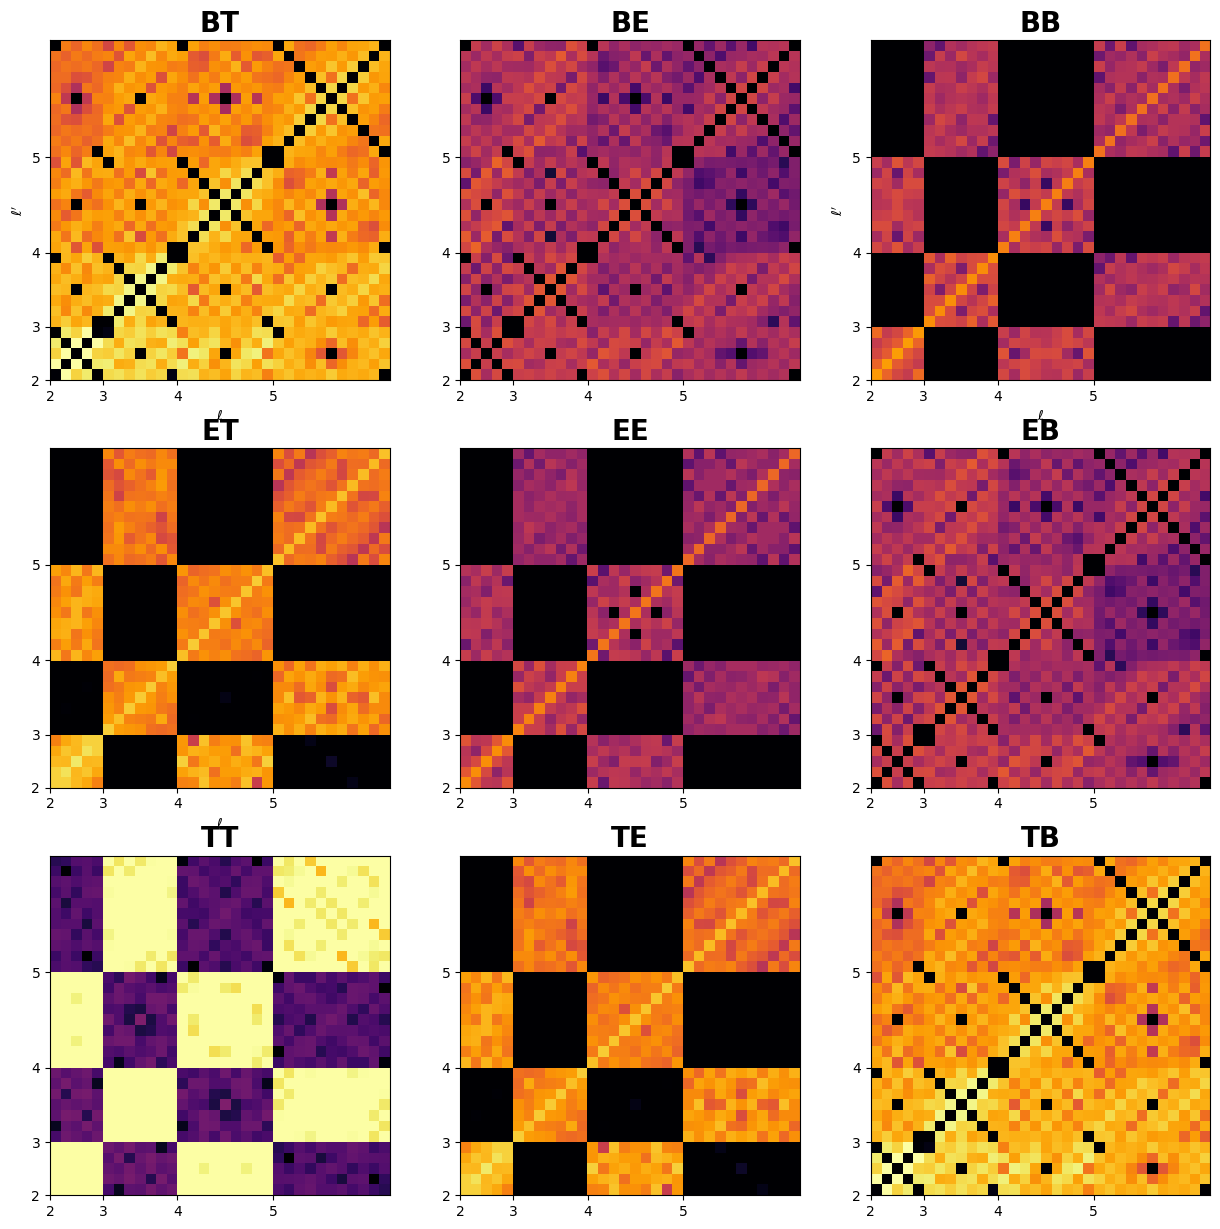

In [25]:
fig, ax = plt.subplots(3,3, figsize=(15,15))
do_cov_sub_plot(ax[0,0], normalize=True, title = 'BT',  ax_index=0, C_order=c_ell_untilted[5], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[0,1], normalize=True, title = 'BE', ax_index=1, C_order=c_ell_untilted[4], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[0,2], normalize=True, title = 'BB', ax_index=2, C_order=c_ell_untilted[2], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[1,0], normalize=True, title = 'ET', ax_index=3, C_order=c_ell_untilted[3], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[1,1], normalize=True, title = 'EE', ax_index=4, C_order=c_ell_untilted[1], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[1,2], normalize=True, title = 'EB', ax_index=5, C_order=c_ell_untilted[4], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[2,0], normalize=True, title = 'TT', ax_index=6, C_order=c_ell_untilted[0], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[2,1], normalize=True, title = 'TE', ax_index=7, C_order=c_ell_untilted[3], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[2,2], normalize=True, title = 'TB', ax_index=8, C_order=c_ell_untilted[5], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))

# 1 Test - Parity for tilted and untilted case

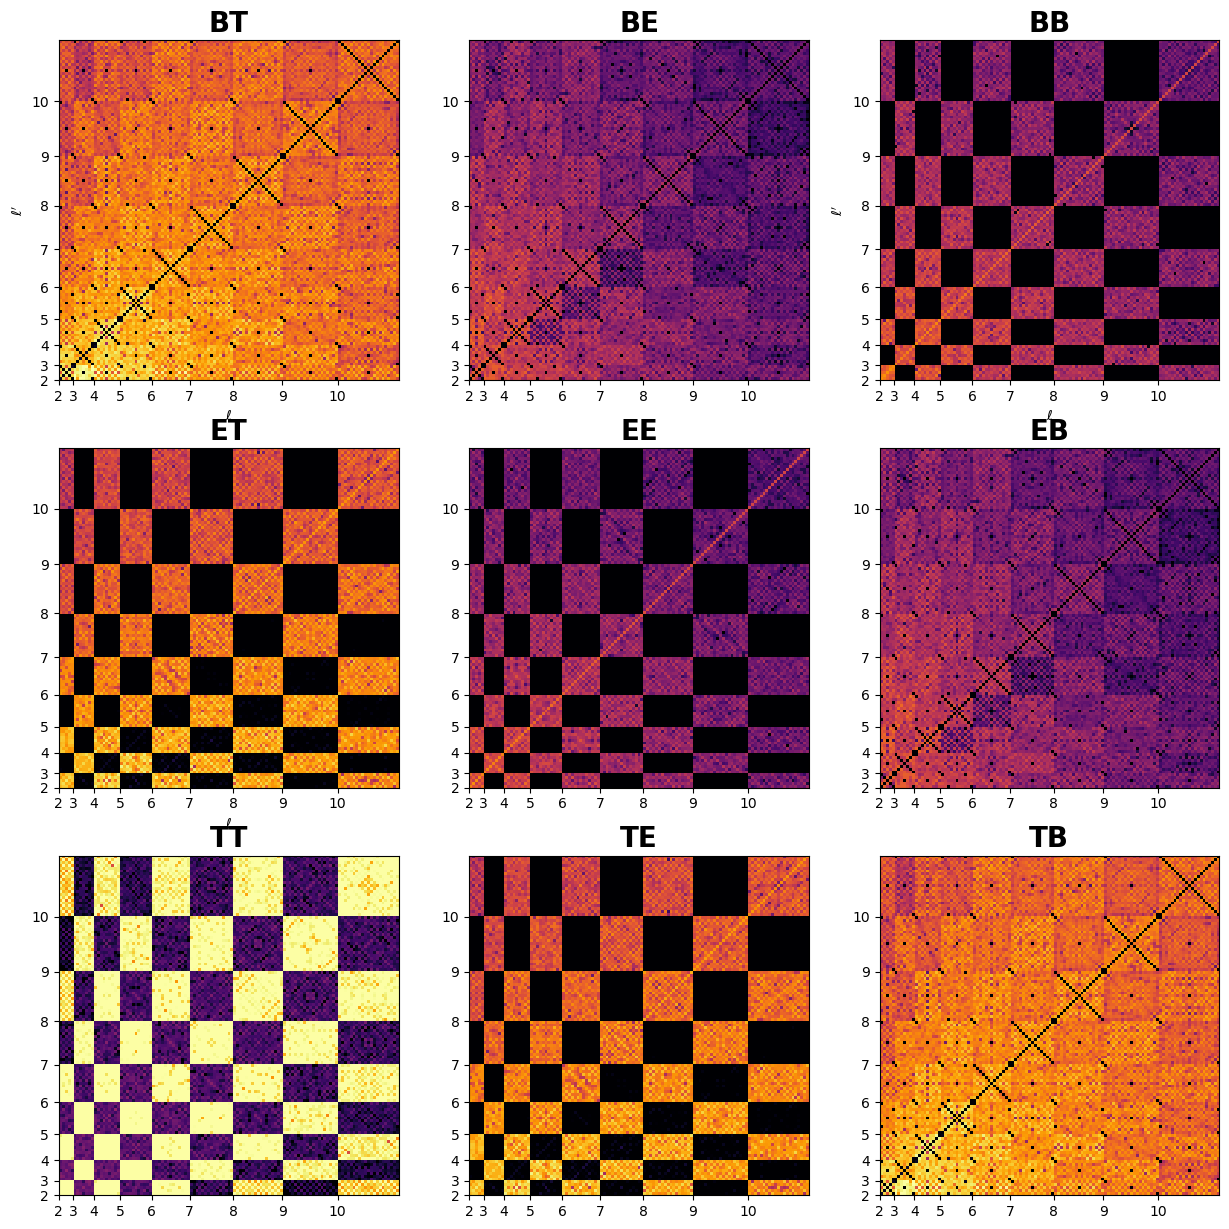

In [14]:
fig, ax = plt.subplots(3,3, figsize=(15,15))
do_cov_sub_plot(ax[0,0], normalize=True, title = 'BT',  ax_index=0, C_order=c_ell_untilted[5], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[0,1], normalize=True, title = 'BE', ax_index=1, C_order=c_ell_untilted[4], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[0,2], normalize=True, title = 'BB', ax_index=2, C_order=c_ell_untilted[2], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[1,0], normalize=True, title = 'ET', ax_index=3, C_order=c_ell_untilted[3], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[1,1], normalize=True, title = 'EE', ax_index=4, C_order=c_ell_untilted[1], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[1,2], normalize=True, title = 'EB', ax_index=5, C_order=c_ell_untilted[4], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[2,0], normalize=True, title = 'TT', ax_index=6, C_order=c_ell_untilted[0], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[2,1], normalize=True, title = 'TE', ax_index=7, C_order=c_ell_untilted[3], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[2,2], normalize=True, title = 'TB', ax_index=8, C_order=c_ell_untilted[5], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))

In [11]:
l_max = 10
#L_circle = 0.73321

c_ell_tilted = run_topology_ricardo(topology = 'E7', LAx = 0.5, LAy = 0.5, L1y = 0.5, L2x = 0.5, L2z = 0.5, 
             l_max = l_max, x0= np.array([0.0,  0.5 * 13824.9 * 2, 0.0], dtype=np.float64), 
             l_range = np.array([[2,l_max]]), lp_range = np.array([[2,l_max]]))

Running - E7 l_max=10_LAx_13824_LAy_13824_L1y_13824_L2x_13824_L2z_13824_x_0.00_y_13824.90_z_0.00
Running {'topology': 'E7', 'LAx': 0.5, 'LAy': 0.5, 'L1y': 0.5, 'L2x': 0.5, 'L2z': 0.5, 'x0': array([    0. , 13824.9,     0. ]), 'c_l_accuracy': 0.99, 'l_max': 10, 'l_min': 2, 'node': 1}
Making run folder: runs/E7_LAx_0.50_LAy_0.50_L1y_0.50_L2x_0.50_L2z_0.50_x_0.00_y_13824.90_z_0.00_l_max_10/
Shape of transfer function from CAMB: (3, 599, 6454)

Finding k_max as a function of ell


100%|██████████| 9/9 [00:00<00:00, 22.20it/s]


Done. k_max for ell_max = 0.020159226527455353
Intervals: 
 1 supspace - [0, 12148] 
 2 subspace - [12148, 723514]
Time to get list of k, phi, theta: 15.345839977264404 seconds
Getting repeated theta and k elements
Ratio of unique theta: 0.11090455747919184
Ratio of unique |k|: 0.004986772888983489
Time to get unique k and theta: 0.09001708030700684 seconds

Getting transfer functions


100%|██████████| 3608/3608 [00:01<00:00, 2139.89it/s]

Size of transfer function: 0.3 MB. 



...

100%|██████████| 3608/3608 [00:01<00:00, 2806.28it/s]

Size of transfer function: 0.3 MB. 




Getting Wigner_d matrices!


100%|██████████| 80241/80241 [00:03<00:00, 21237.58it/s]


The Wigner_d metrices array is 77.14 MB 


**************
Done with all preprocessing
**************

Time to pre-process with l_max=10 and accuracy=0.99: 56.68593096733093 seconds

Calculating covariance matrix
Size of integrand: 19.98 MB.
Time to get Correlation functions: 0:4:15


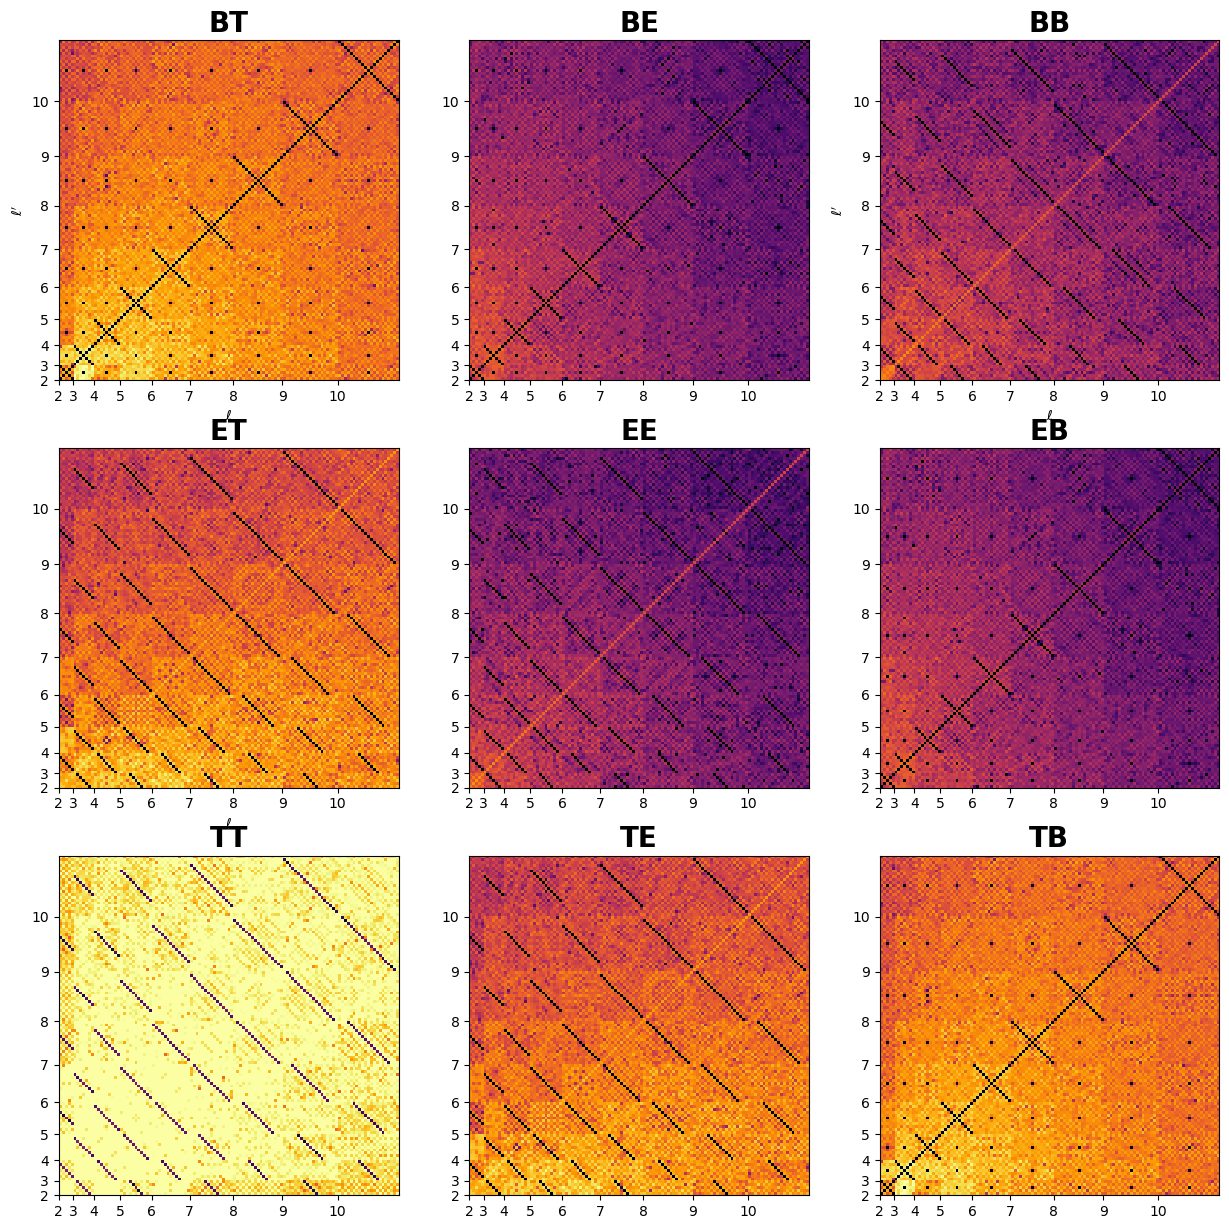

In [12]:
fig, ax = plt.subplots(3,3, figsize=(15,15))
do_cov_sub_plot(ax[0,0], normalize=True, title = 'BT',  ax_index=0, C_order=c_ell_tilted[5], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[0,1], normalize=True, title = 'BE', ax_index=1, C_order=c_ell_tilted[4], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[0,2], normalize=True, title = 'BB', ax_index=2, C_order=c_ell_tilted[2], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[1,0], normalize=True, title = 'ET', ax_index=3, C_order=c_ell_tilted[3], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[1,1], normalize=True, title = 'EE', ax_index=4, C_order=c_ell_tilted[1], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[1,2], normalize=True, title = 'EB', ax_index=5, C_order=c_ell_tilted[4], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[2,0], normalize=True, title = 'TT', ax_index=6, C_order=c_ell_tilted[0], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[2,1], normalize=True, title = 'TE', ax_index=7, C_order=c_ell_tilted[3], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[2,2], normalize=True, title = 'TB', ax_index=8, C_order=c_ell_tilted[5], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))

In [19]:
l_max = 10
#L_circle = 0.73321

c_ell_untilted = run_topology_ricardo(topology = 'E7', LAx = 0.5, LAy = 0.5, L1y = 0.5, L2x = 0.0, L2z = 0.5, 
             l_max = l_max, x0= np.array([0.0, 0.0, 0.0], dtype=np.float64), 
             l_range = np.array([[2,l_max]]), lp_range = np.array([[2,l_max]]))

Running - E7 l_max=10_LAx_13824_LAy_13824_L1y_13824_L2x_0_L2z_13824_x_0.00_y_0.00_z_0.00
Running {'topology': 'E7', 'LAx': 0.5, 'LAy': 0.5, 'L1y': 0.5, 'L2x': 0.0, 'L2z': 0.5, 'x0': array([0., 0., 0.]), 'c_l_accuracy': 0.99, 'l_max': 10, 'l_min': 2, 'node': 1}
Making run folder: runs/E7_LAx_0.50_LAy_0.50_L1y_0.50_L2x_0.00_L2z_0.50_x_0.00_y_0.00_z_0.00_l_max_10/
Shape of transfer function from CAMB: (3, 599, 6454)

Finding k_max as a function of ell


100%|██████████| 9/9 [00:00<00:00, 24.27it/s]


Done. k_max for ell_max = 0.020159226527455353
Intervals: 
 1 supspace - [0, 12100] 
 2 subspace - [12100, 721852]
Time to get list of k, phi, theta: 9.46402096748352 seconds
Getting repeated theta and k elements
Ratio of unique theta: 0.1104062882696176
Ratio of unique |k|: 0.004998254489840022
Time to get unique k and theta: 0.0897982120513916 seconds

Getting transfer functions


100%|██████████| 3608/3608 [00:01<00:00, 1891.78it/s]

Size of transfer function: 0.3 MB. 



...


Getting transfer functions


100%|██████████| 3608/3608 [00:01<00:00, 2164.60it/s]


Size of transfer function: 0.3 MB. 


Getting Wigner_d matrices!


100%|██████████| 79697/79697 [00:05<00:00, 14761.02it/s]


The Wigner_d metrices array is 76.61 MB 


**************
Done with all preprocessing
**************

Time to pre-process with l_max=10 and accuracy=0.99: 51.65097689628601 seconds

Calculating covariance matrix
Size of integrand: 19.98 MB.
Time to get Correlation functions: 0:4:7


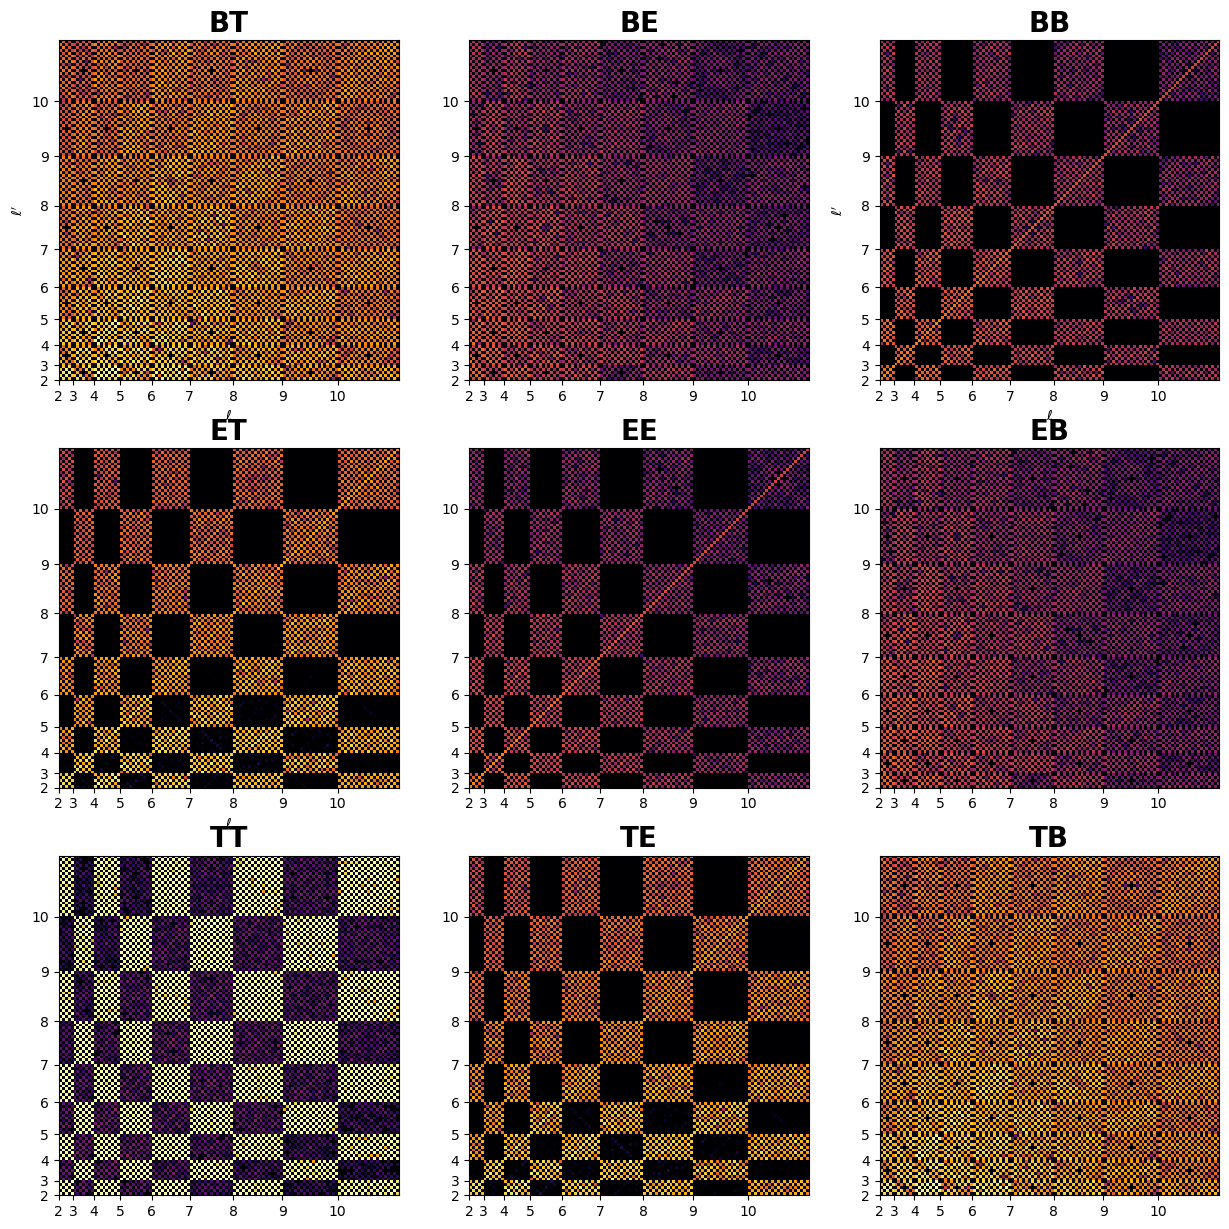

In [22]:
fig, ax = plt.subplots(3,3, figsize=(15,15))
do_cov_sub_plot(ax[0,0], normalize=True, title = 'BT',  ax_index=0, C_order=c_ell_untilted[5], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[0,1], normalize=True, title = 'BE', ax_index=1, C_order=c_ell_untilted[4], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[0,2], normalize=True, title = 'BB', ax_index=2, C_order=c_ell_untilted[2], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[1,0], normalize=True, title = 'ET', ax_index=3, C_order=c_ell_untilted[3], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[1,1], normalize=True, title = 'EE', ax_index=4, C_order=c_ell_untilted[1], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[1,2], normalize=True, title = 'EB', ax_index=5, C_order=c_ell_untilted[4], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[2,0], normalize=True, title = 'TT', ax_index=6, C_order=c_ell_untilted[0], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[2,1], normalize=True, title = 'TE', ax_index=7, C_order=c_ell_untilted[3], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[2,2], normalize=True, title = 'TB', ax_index=8, C_order=c_ell_untilted[5], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))

In [ ]:
l_max = 10
#L_circle = 0.73321

c_ell_tilted = run_topology_ricardo(topology = 'E7', LAx = 0.5, LAy = 0.5, L1y = 0.5, L2x = 0.0, L2z = 0.5, 
             l_max = l_max, x0= np.array([0.0, 0.5 , 0.0], dtype=np.float64), 
             l_range = np.array([[2,l_max]]), lp_range = np.array([[2,l_max]]))

Running - E7 l_max=10_LAx_13824_LAy_13824_L1y_13824_L2x_0_L2z_13824_x_0.00_y_13824.90_z_0.00
Running {'topology': 'E7', 'LAx': 0.5, 'LAy': 0.5, 'L1y': 0.5, 'L2x': 0.0, 'L2z': 0.5, 'x0': array([    0. , 13824.9,     0. ]), 'c_l_accuracy': 0.99, 'l_max': 10, 'l_min': 2, 'node': 1}
Making run folder: runs/E7_LAx_0.50_LAy_0.50_L1y_0.50_L2x_0.00_L2z_0.50_x_0.00_y_13824.90_z_0.00_l_max_10/
Shape of transfer function from CAMB: (3, 599, 6454)

Finding k_max as a function of ell


100%|██████████| 9/9 [00:00<00:00, 24.60it/s]


Done. k_max for ell_max = 0.020159226527455353
Intervals: 
 1 supspace - [0, 12100] 
 2 subspace - [12100, 721852]
Time to get list of k, phi, theta: 9.882970094680786 seconds
Getting repeated theta and k elements
Ratio of unique theta: 0.1104062882696176
Ratio of unique |k|: 0.004998254489840022
Time to get unique k and theta: 0.09451103210449219 seconds

Getting transfer functions


100%|██████████| 3608/3608 [00:02<00:00, 1734.44it/s]

Size of transfer function: 0.3 MB. 



...

100%|██████████| 3608/3608 [00:01<00:00, 2562.90it/s]

Size of transfer function: 0.3 MB. 




Getting Wigner_d matrices!


100%|██████████| 79697/79697 [00:04<00:00, 18837.64it/s] 


The Wigner_d metrices array is 76.61 MB 


**************
Done with all preprocessing
**************

Time to pre-process with l_max=10 and accuracy=0.99: 56.6285457611084 seconds

Calculating covariance matrix
Size of integrand: 19.98 MB.
Time to get Correlation functions: 0:4:15


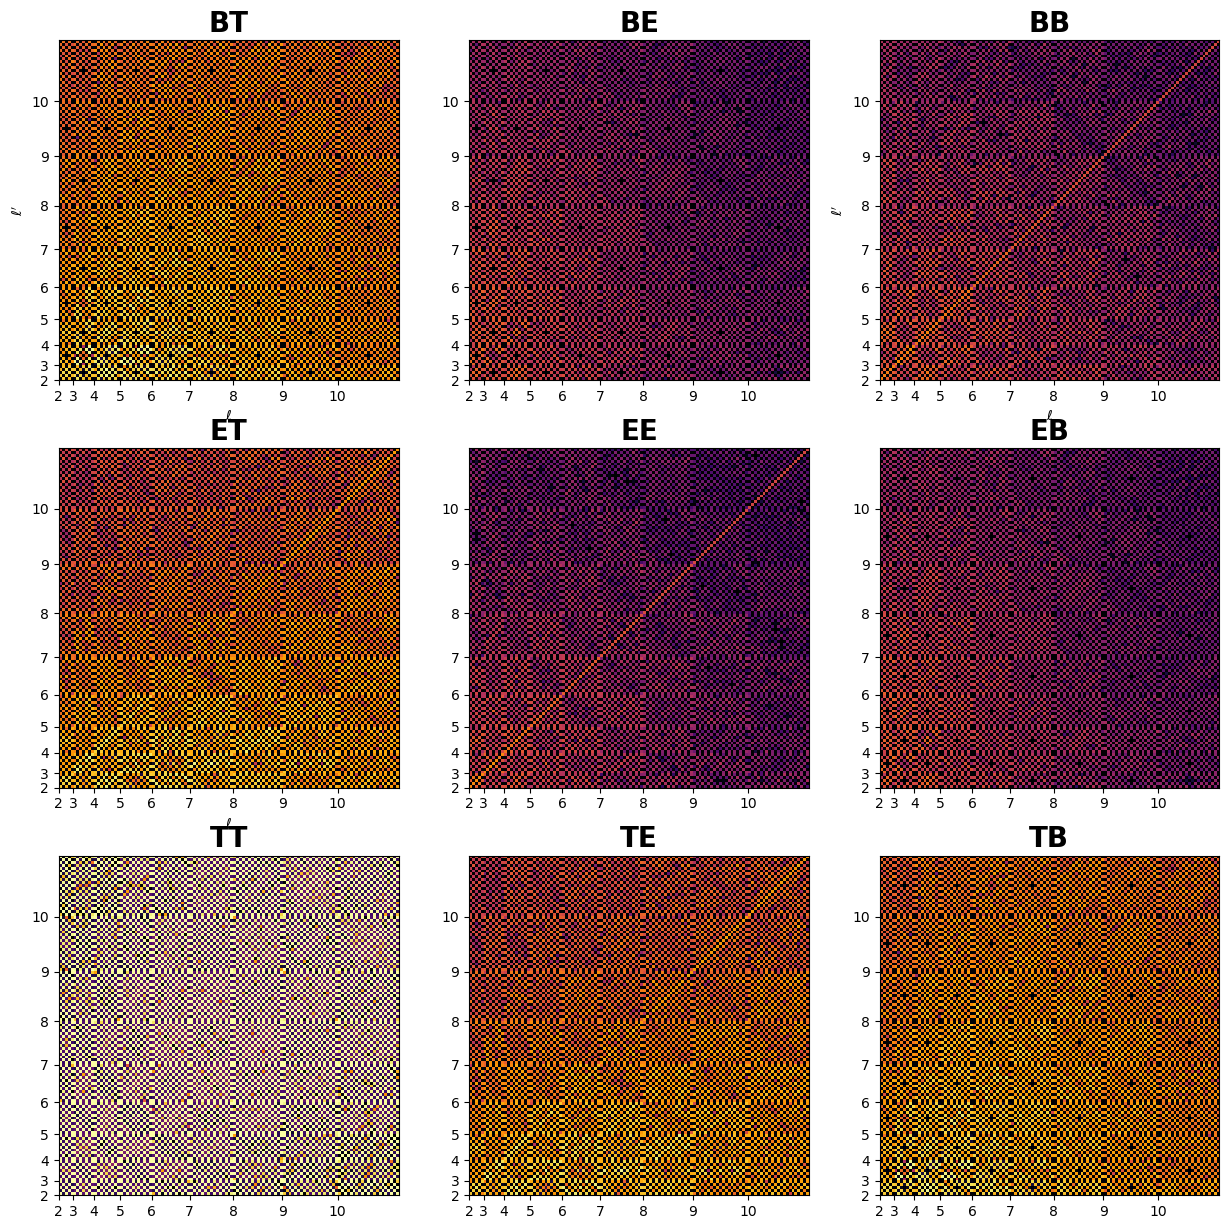

In [21]:
fig, ax = plt.subplots(3,3, figsize=(15,15))
do_cov_sub_plot(ax[0,0], normalize=True, title = 'BT',  ax_index=0, C_order=c_ell_tilted[5], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[0,1], normalize=True, title = 'BE', ax_index=1, C_order=c_ell_tilted[4], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[0,2], normalize=True, title = 'BB', ax_index=2, C_order=c_ell_tilted[2], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[1,0], normalize=True, title = 'ET', ax_index=3, C_order=c_ell_tilted[3], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[1,1], normalize=True, title = 'EE', ax_index=4, C_order=c_ell_tilted[1], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[1,2], normalize=True, title = 'EB', ax_index=5, C_order=c_ell_tilted[4], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[2,0], normalize=True, title = 'TT', ax_index=6, C_order=c_ell_tilted[0], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[2,1], normalize=True, title = 'TE', ax_index=7, C_order=c_ell_tilted[3], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[2,2], normalize=True, title = 'TB', ax_index=8, C_order=c_ell_tilted[5], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))

# 2 - Equal Manifold

In [ ]:
l_max = 10
#L_circle = 0.73321

c_ell_untilted = run_topology_ricardo(topology = 'E7', LAx = 0.5, LAy = 0.5, L1y = 0.5, L2x = 0.5, L2z = 0.5, 
             l_max = l_max, x0= np.array([0.0,  0.0, 0.0], dtype=np.float64), 
             l_range = np.array([[2,l_max]]), lp_range = np.array([[2,l_max]]))

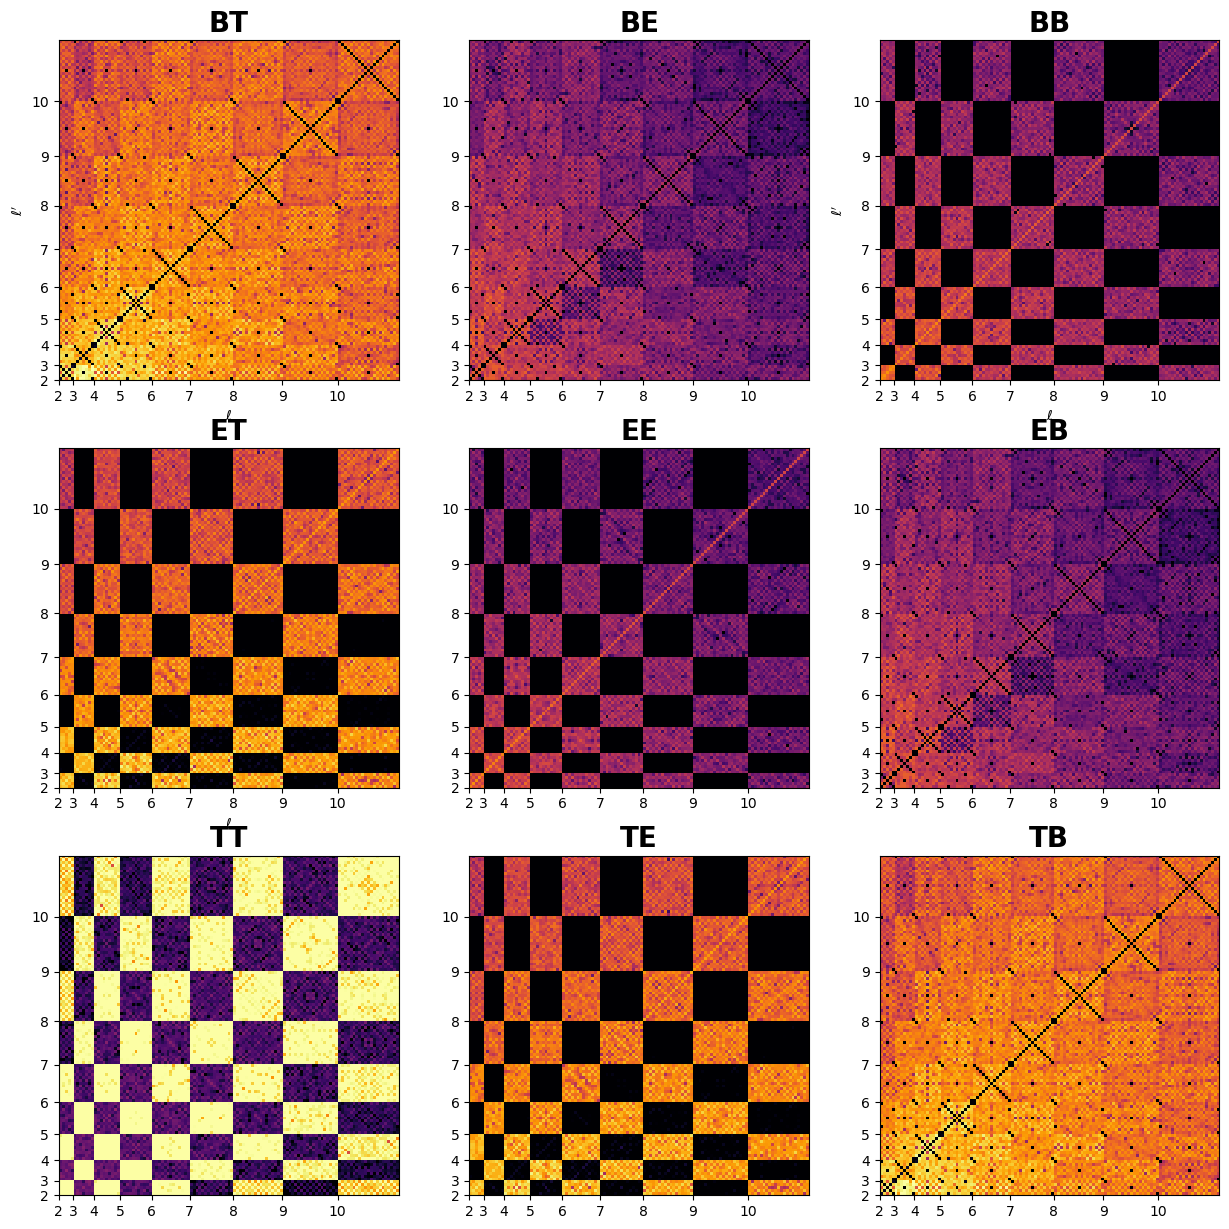

In [15]:
fig, ax = plt.subplots(3,3, figsize=(15,15))
do_cov_sub_plot(ax[0,0], normalize=True, title = 'BT',  ax_index=0, C_order=c_ell_untilted[5], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[0,1], normalize=True, title = 'BE', ax_index=1, C_order=c_ell_untilted[4], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[0,2], normalize=True, title = 'BB', ax_index=2, C_order=c_ell_untilted[2], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[1,0], normalize=True, title = 'ET', ax_index=3, C_order=c_ell_untilted[3], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[1,1], normalize=True, title = 'EE', ax_index=4, C_order=c_ell_untilted[1], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[1,2], normalize=True, title = 'EB', ax_index=5, C_order=c_ell_untilted[4], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[2,0], normalize=True, title = 'TT', ax_index=6, C_order=c_ell_untilted[0], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[2,1], normalize=True, title = 'TE', ax_index=7, C_order=c_ell_untilted[3], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[2,2], normalize=True, title = 'TB', ax_index=8, C_order=c_ell_untilted[5], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))

In [16]:
X_x_prime = 0.2 * 13824.9 * 2 
X_y_prime = 0.2 * 13824.9 * 2

L_Ax_prime = 0.5
L_Ay_prime = 0.5 - (2 * (X_y_prime))

l_max = 10
#L_circle = 0.73321

c_ell_tilted = run_topology_ricardo(topology = 'E7', LAx = L_Ax_prime, LAy = L_Ay_prime, L1y = 0.5, L2x = 0.5, L2z = 0.5, 
             l_max = l_max, x0= np.array([X_x_prime,  X_y_prime, 0.0], dtype=np.float64), 
             l_range = np.array([[2,l_max]]), lp_range = np.array([[2,l_max]]))

Running - E7 l_max=10_LAx_13824_LAy_-305790751_L1y_13824_L2x_13824_L2z_13824_x_5529.96_y_5529.96_z_0.00
Running {'topology': 'E7', 'LAx': 0.5, 'LAy': -11059.42, 'L1y': 0.5, 'L2x': 0.5, 'L2z': 0.5, 'x0': array([5529.96, 5529.96,    0.  ]), 'c_l_accuracy': 0.99, 'l_max': 10, 'l_min': 2, 'node': 1}
Making run folder: runs/E7_LAx_0.50_LAy_-11059.42_L1y_0.50_L2x_0.50_L2z_0.50_x_5529.96_y_5529.96_z_0.00_l_max_10/
Shape of transfer function from CAMB: (3, 599, 6454)

Finding k_max as a function of ell


100%|██████████| 9/9 [00:00<00:00, 21.99it/s]


Done. k_max for ell_max = 0.020159226527455353
Intervals: 
 1 supspace - [0, 12148] 
 2 subspace - [12148, 723514]
Time to get list of k, phi, theta: 15.016189098358154 seconds
Getting repeated theta and k elements
Ratio of unique theta: 0.11090455747919184
Ratio of unique |k|: 0.004986772888983489
Time to get unique k and theta: 0.08834409713745117 seconds

Getting transfer functions


100%|██████████| 3608/3608 [00:02<00:00, 1781.20it/s]

Size of transfer function: 0.3 MB. 



...

100%|██████████| 3608/3608 [00:01<00:00, 2280.33it/s]

Size of transfer function: 0.3 MB. 




Getting Wigner_d matrices!


100%|██████████| 80241/80241 [00:04<00:00, 17050.55it/s]


The Wigner_d metrices array is 77.14 MB 


**************
Done with all preprocessing
**************

Time to pre-process with l_max=10 and accuracy=0.99: 55.85933208465576 seconds

Calculating covariance matrix
Size of integrand: 19.98 MB.
Time to get Correlation functions: 0:3:55


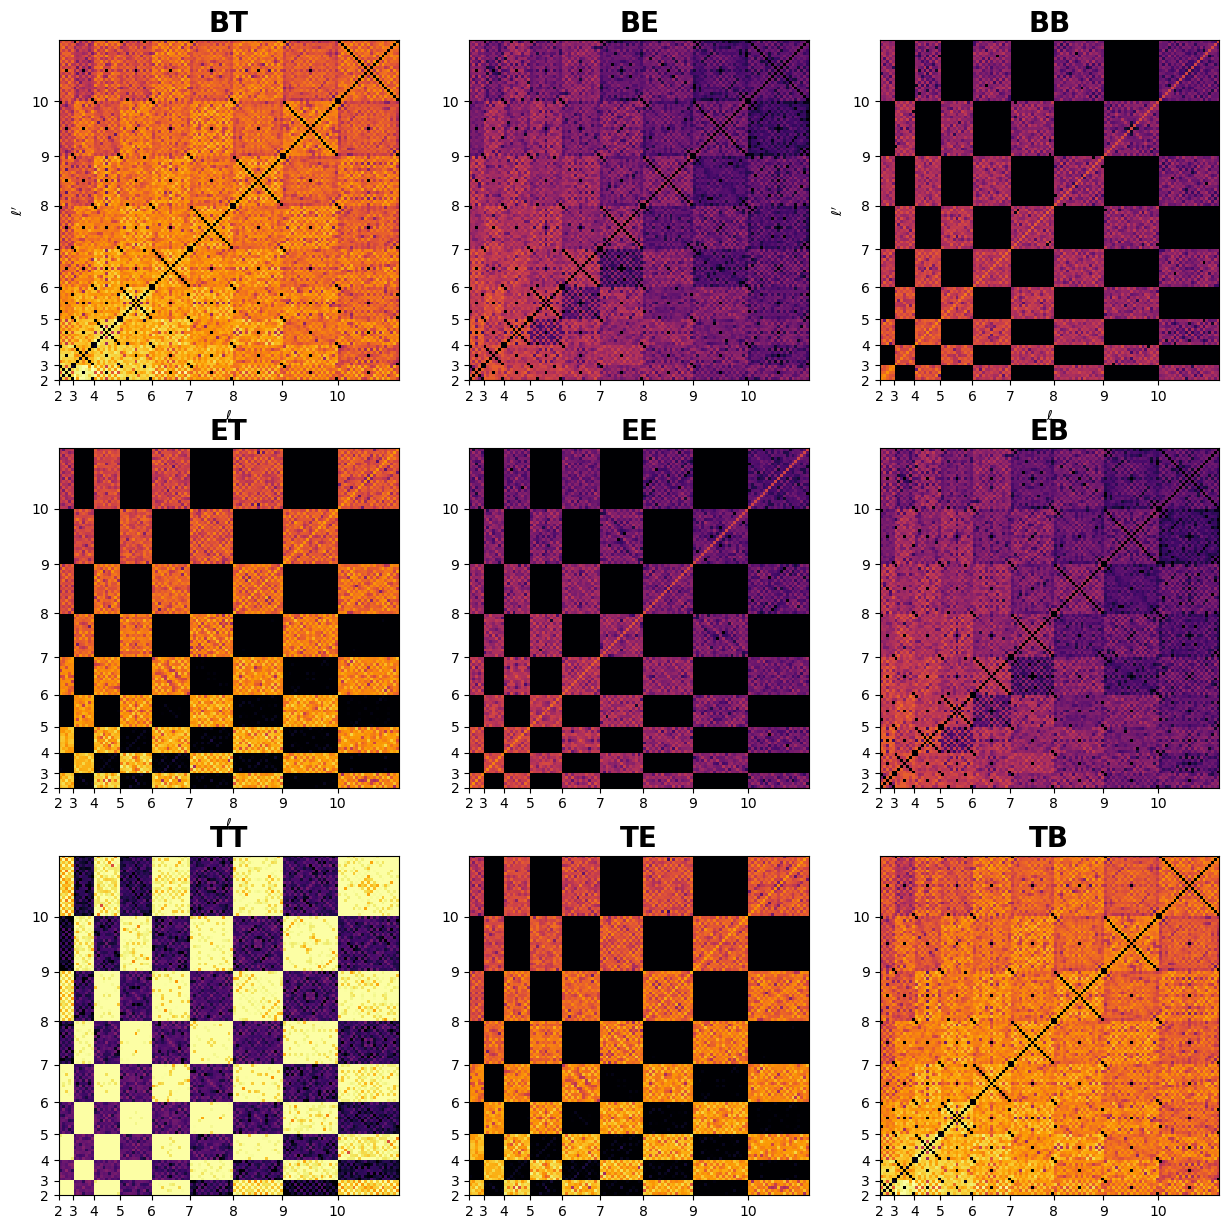

In [18]:
fig, ax = plt.subplots(3,3, figsize=(15,15))
do_cov_sub_plot(ax[0,0], normalize=True, title = 'BT',  ax_index=0, C_order=c_ell_tilted[5], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[0,1], normalize=True, title = 'BE', ax_index=1, C_order=c_ell_tilted[4], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[0,2], normalize=True, title = 'BB', ax_index=2, C_order=c_ell_tilted[2], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[1,0], normalize=True, title = 'ET', ax_index=3, C_order=c_ell_tilted[3], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[1,1], normalize=True, title = 'EE', ax_index=4, C_order=c_ell_tilted[1], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[1,2], normalize=True, title = 'EB', ax_index=5, C_order=c_ell_tilted[4], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[2,0], normalize=True, title = 'TT', ax_index=6, C_order=c_ell_tilted[0], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[2,1], normalize=True, title = 'TE', ax_index=7, C_order=c_ell_tilted[3], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[2,2], normalize=True, title = 'TB', ax_index=8, C_order=c_ell_tilted[5], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))

In [ ]:
l_max = 10
#L_circle = 0.73321

c_ell_untilted = run_topology_ricardo(topology = 'E7', LAx = 1, LAy = 0, L1y = 1.4, L2x = 0.7, L2z = 1, 
             l_max = l_max, x0= np.array([0.0, 0.0, 0.0], dtype=np.float64), 
             l_range = np.array([[2,l_max]]), lp_range = np.array([[2,l_max]]))

Running - E7 l_max=10_LAx_27649_LAy_0_L1y_38709_L2x_19354_L2z_27649_x_0.00_y_0.00_z_0.00
Running {'topology': 'E7', 'LAx': 1, 'LAy': 0, 'L1y': 1.4, 'L2x': 0.7, 'L2z': 1, 'x0': array([0., 0., 0.]), 'c_l_accuracy': 0.99, 'l_max': 10, 'l_min': 2, 'node': 1}
Shape of transfer function from CAMB: (3, 599, 6454)

Finding k_max as a function of ell


100%|██████████| 9/9 [00:00<00:00, 24.69it/s]


Done. k_max for ell_max = 0.020159226527455353
Intervals: 
 1 supspace - [0, 48996] 
 2 subspace - [48996, 8142756]
Time to get list of k, phi, theta: 141.06450700759888 seconds
Getting repeated theta and k elements
Ratio of unique theta: 0.3630100177384659
Ratio of unique |k|: 0.020762503506183902
Time to get unique k and theta: 1.482292890548706 seconds

Getting transfer functions


100%|██████████| 169064/169064 [00:08<00:00, 19367.12it/s]


Size of transfer function: 14.19 MB. 


Getting transfer functions


...

100%|██████████| 169064/169064 [00:06<00:00, 24465.08it/s]


Size of transfer function: 14.19 MB. 


Getting Wigner_d matrices!


100%|██████████| 2955902/2955902 [02:14<00:00, 21998.09it/s] 


The Wigner_d metrices array is 2841.52 MB 


**************
Done with all preprocessing
**************

Time to pre-process with l_max=10 and accuracy=0.99: 420.63366293907166 seconds

Calculating covariance matrix
Size of integrand: 936.44 MB.


python(32813) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(32990) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(33424) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


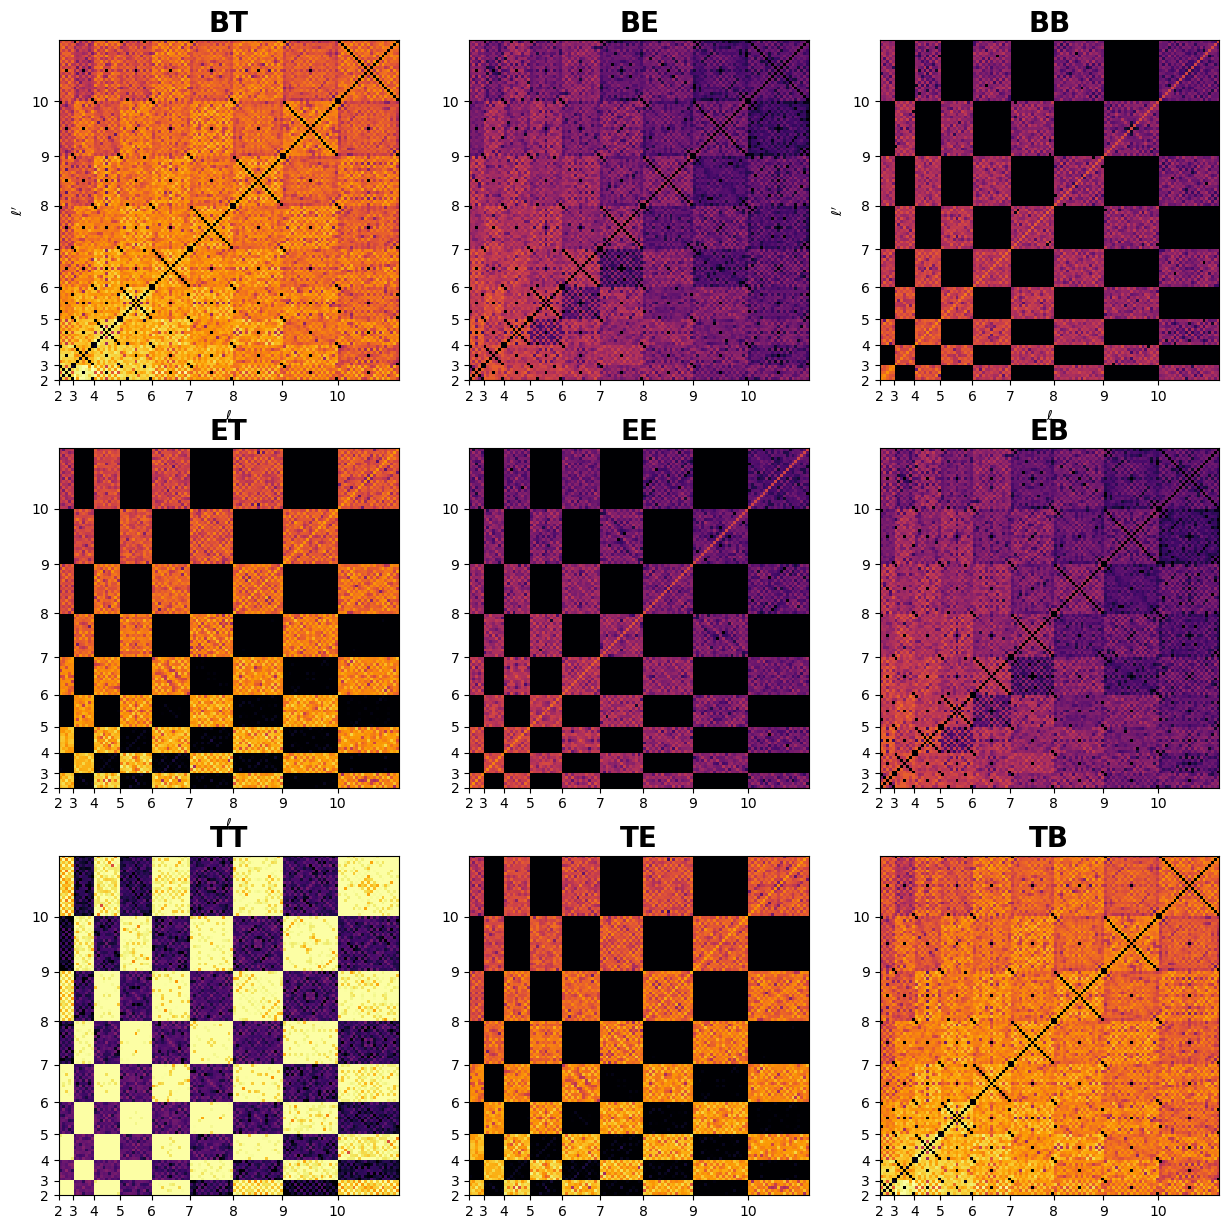

In [17]:
fig, ax = plt.subplots(3,3, figsize=(15,15))
do_cov_sub_plot(ax[0,0], normalize=True, title = 'BT',  ax_index=0, C_order=c_ell_tilted[5], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[0,1], normalize=True, title = 'BE', ax_index=1, C_order=c_ell_tilted[4], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[0,2], normalize=True, title = 'BB', ax_index=2, C_order=c_ell_tilted[2], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[1,0], normalize=True, title = 'ET', ax_index=3, C_order=c_ell_tilted[3], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[1,1], normalize=True, title = 'EE', ax_index=4, C_order=c_ell_tilted[1], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[1,2], normalize=True, title = 'EB', ax_index=5, C_order=c_ell_tilted[4], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[2,0], normalize=True, title = 'TT', ax_index=6, C_order=c_ell_tilted[0], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[2,1], normalize=True, title = 'TE', ax_index=7, C_order=c_ell_tilted[3], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[2,2], normalize=True, title = 'TB', ax_index=8, C_order=c_ell_tilted[5], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))

In [2]:
l_max = 10
#L_circle = 0.73321

c_ell = run_topology_ricardo(topology = 'E7', LAx = 0.1, LAy = 0.1, L1y = 0.1, L2x = 0.1, L2z = 0.1, 
             l_max = l_max, x0= np.array([0.0, 0.0, 0.0], dtype=np.float64), 
             l_range = np.array([[2,l_max]]), lp_range = np.array([[2,l_max]]))

Running - E7 l_max=10_LAx_2764_LAy_2764_L1y_2764_L2x_2764_L2z_2764_x_0.00_y_0.00_z_0.00
Running {'topology': 'E7', 'LAx': 0.1, 'LAy': 0.1, 'L1y': 0.1, 'L2x': 0.1, 'L2z': 0.1, 'x0': array([0., 0., 0.]), 'c_l_accuracy': 0.99, 'l_max': 10, 'l_min': 2, 'node': 1}
Shape of transfer function from CAMB: (3, 599, 6454)

Finding k_max as a function of ell


100%|██████████| 9/9 [00:00<00:00, 21.62it/s]


Done. k_max for ell_max = 0.020159226527455353
Intervals: 
 1 supspace - [0, 456] 
 2 subspace - [456, 5606]
Time to get list of k, phi, theta: 0.4761769771575928 seconds
Getting repeated theta and k elements
Ratio of unique theta: 0.15037459864430966
Ratio of unique |k|: 0.026043524794862646
Time to get unique k and theta: 0.0037109851837158203 seconds

Getting transfer functions


100%|██████████| 146/146 [00:02<00:00, 71.77it/s]

Size of transfer function: 0.01 MB. 



...

100%|██████████| 146/146 [00:01<00:00, 104.00it/s]

Size of transfer function: 0.01 MB. 




Getting Wigner_d matrices!


100%|██████████| 843/843 [00:00<00:00, 866.41it/s]


The Wigner_d metrices array is 0.81 MB 


**************
Done with all preprocessing
**************

Time to pre-process with l_max=10 and accuracy=0.99: 41.13801598548889 seconds

Calculating covariance matrix
Size of integrand: 0.81 MB.
Time to get Correlation functions: 0:0:12


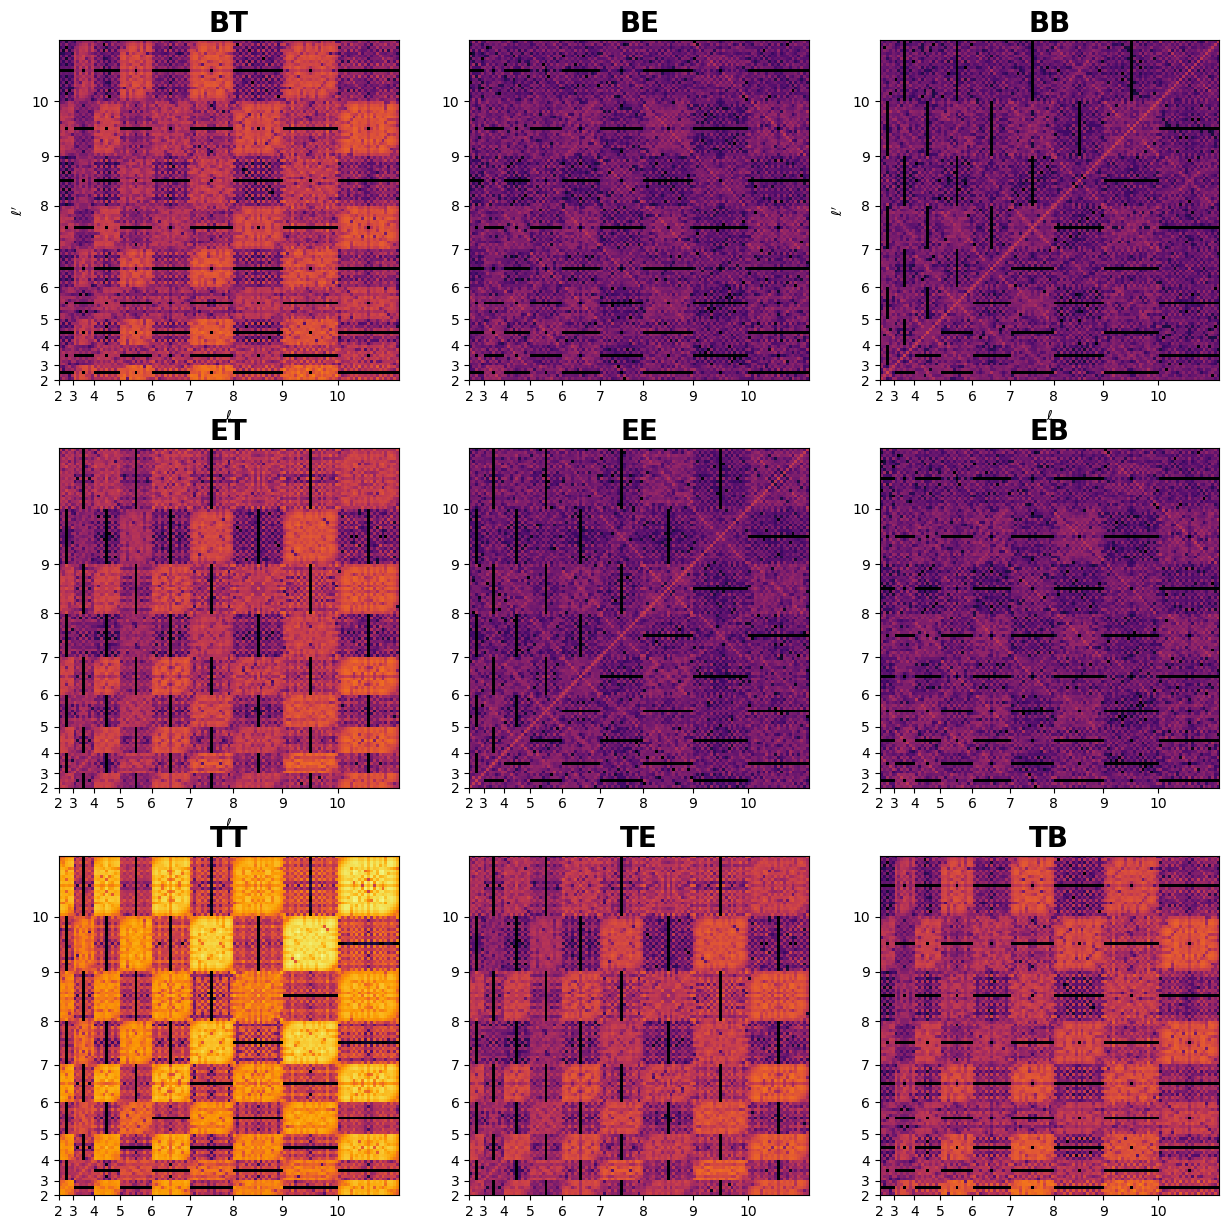

In [3]:
fig, ax = plt.subplots(3,3, figsize=(15,15))
do_cov_sub_plot(ax[0,0], normalize=True, title = 'BT',  ax_index=0, C_order=c_ell[5], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[0,1], normalize=True, title = 'BE', ax_index=1, C_order=c_ell[4], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[0,2], normalize=True, title = 'BB', ax_index=2, C_order=c_ell[2], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[1,0], normalize=True, title = 'ET', ax_index=3, C_order=c_ell[3], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[1,1], normalize=True, title = 'EE', ax_index=4, C_order=c_ell[1], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[1,2], normalize=True, title = 'EB', ax_index=5, C_order=c_ell[4], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[2,0], normalize=True, title = 'TT', ax_index=6, C_order=c_ell[0], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[2,1], normalize=True, title = 'TE', ax_index=7, C_order=c_ell[3], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[2,2], normalize=True, title = 'TB', ax_index=8, C_order=c_ell[5], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))

In [15]:
l_max = 3
#L_circle = 0.73321

c_ell = run_topology_ricardo(topology = 'E7', LAx = 2, LAy = 2, L1y = 2, L2x = 2, L2z = 2, 
             l_max = l_max, x0= np.array([0.0, 0.0, 0.0], dtype=np.float64), 
             l_range = np.array([[2,l_max]]), lp_range = np.array([[2,l_max]]))

Running - E7 l_max=3_LAx_55299_LAy_55299_L1y_55299_L2x_55299_L2z_55299_x_0.00_y_0.00_z_0.00
Running {'topology': 'E7', 'LAx': 2, 'LAy': 2, 'L1y': 2, 'L2x': 2, 'L2z': 2, 'x0': array([0., 0., 0.]), 'c_l_accuracy': 0.99, 'l_max': 3, 'l_min': 2, 'node': 1}
Making run folder: runs/E7_LAx_2.00_LAy_2.00_L1y_2.00_L2x_2.00_L2z_2.00_x_0.00_y_0.00_z_0.00_l_max_3/
Shape of transfer function from CAMB: (3, 599, 6454)

Finding k_max as a function of ell


100%|██████████| 2/2 [00:00<00:00, 20.71it/s]

Done. k_max for ell_max = 0.007719712952095714


Intervals: 
 1 supspace - [0, 28670] 
 2 subspace - [28670, 2609491]
Time to get list of k, phi, theta: 58.05878925323486 seconds
Getting repeated theta and k elements
Ratio of unique theta: 0.10452574850804237
Ratio of unique |k|: 0.003243544430695488
Time to get unique k and theta: 0.3736240863800049 seconds

Getting transfer functions


100%|██████████| 8464/8464 [00:01<00:00, 4476.52it/s]

...


Getting transfer functions


100%|██████████| 8464/8464 [00:01<00:00, 5781.21it/s]


Size of transfer function: 0.26 MB. 


Getting Wigner_d matrices!


100%|██████████| 272759/272759 [00:05<00:00, 47252.07it/s]


The Wigner_d metrices array is 29.13 MB 


**************
Done with all preprocessing
**************

Time to pre-process with l_max=3 and accuracy=0.99: 102.50688672065735 seconds

Calculating covariance matrix
Size of integrand: 6.2 MB.
Time to get Correlation functions: 0:0:7


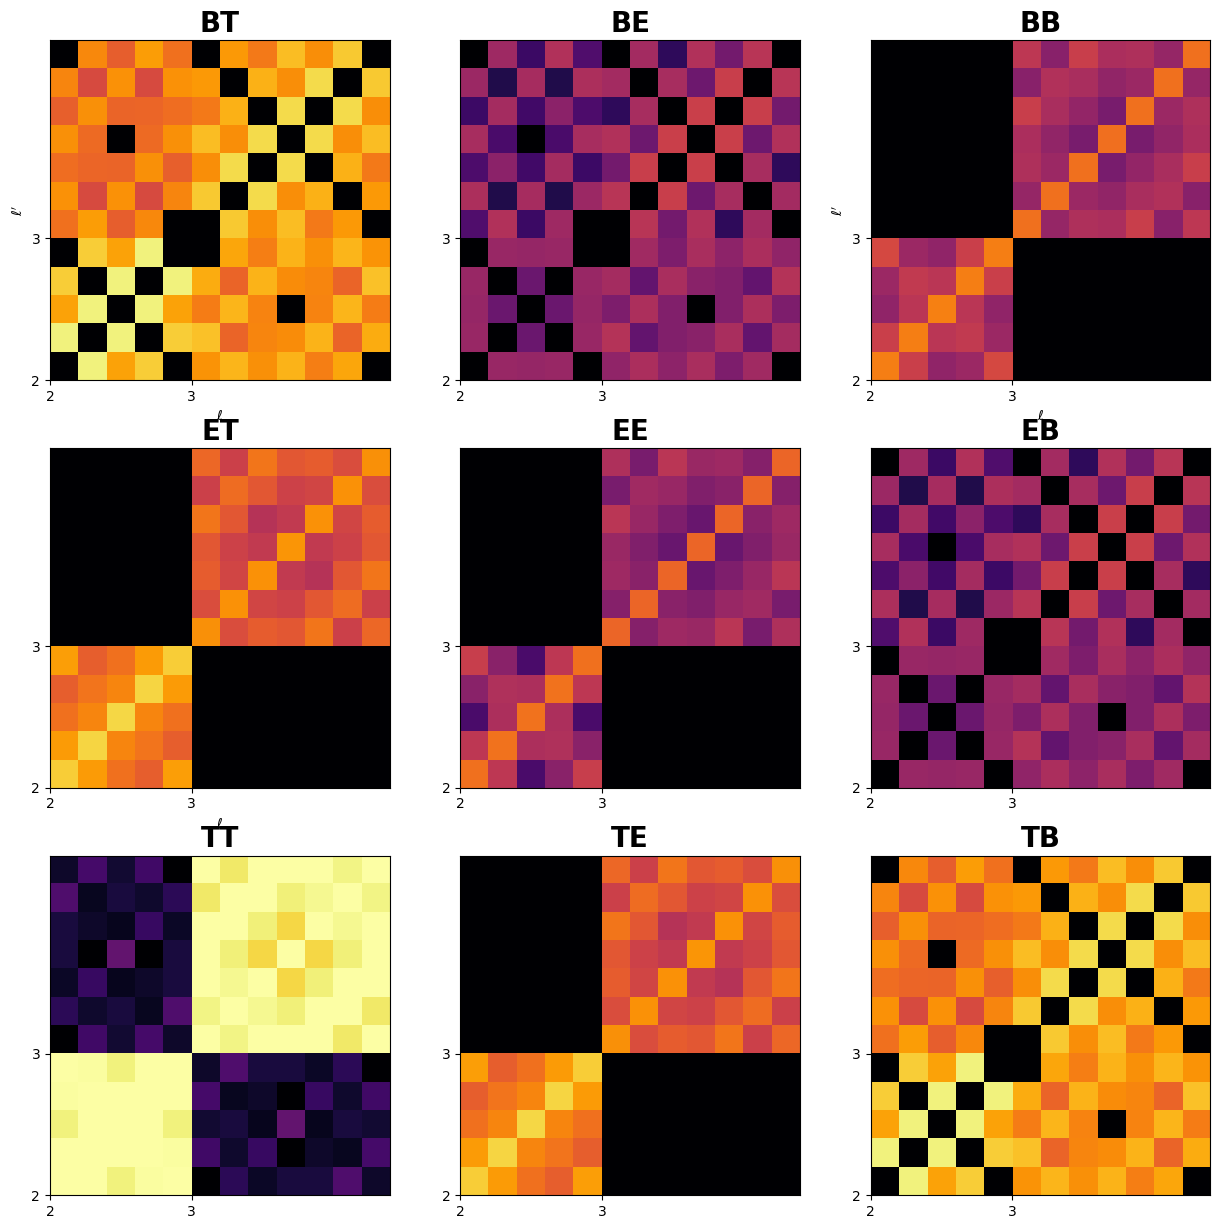

In [17]:
fig, ax = plt.subplots(3,3, figsize=(15,15))
do_cov_sub_plot(ax[0,0], normalize=True, title = 'BT',  ax_index=0, C_order=c_ell[5], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[0,1], normalize=True, title = 'BE', ax_index=1, C_order=c_ell[4], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[0,2], normalize=True, title = 'BB', ax_index=2, C_order=c_ell[2], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[1,0], normalize=True, title = 'ET', ax_index=3, C_order=c_ell[3], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[1,1], normalize=True, title = 'EE', ax_index=4, C_order=c_ell[1], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[1,2], normalize=True, title = 'EB', ax_index=5, C_order=c_ell[4], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[2,0], normalize=True, title = 'TT', ax_index=6, C_order=c_ell[0], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[2,1], normalize=True, title = 'TE', ax_index=7, C_order=c_ell[3], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[2,2], normalize=True, title = 'TB', ax_index=8, C_order=c_ell[5], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))

In [4]:
l_max = 5
L_circle = 1

c_ell_left = run_topology_ricardo(topology = 'E7', LAx = L_circle, LAy = 0, L1y = 1.4, L2x = 0.7, L2z = 1, 
             l_max = l_max, x0= np.array([0.0, 0.0, 0.0], dtype=np.float64), 
             l_range = np.array([[2,l_max]]), lp_range = np.array([[2,l_max]]))

Running - E7 l_max=5_LAx_27649_LAy_0_L1y_38709_L2x_19354_L2z_27649_x_0.00_y_0.00_z_0.00
Running {'topology': 'E7', 'LAx': 1, 'LAy': 0, 'L1y': 1.4, 'L2x': 0.7, 'L2z': 1, 'x0': array([0., 0., 0.]), 'c_l_accuracy': 0.99, 'l_max': 5, 'l_min': 2, 'node': 1}
Shape of transfer function from CAMB: (3, 599, 6454)

Finding k_max as a function of ell


100%|██████████| 4/4 [00:00<00:00, 20.60it/s]


Done. k_max for ell_max = 0.01102416508743576
Intervals: 
 1 supspace - [0, 14544] 
 2 subspace - [14544, 1325505]
Time to get list of k, phi, theta: 26.820178985595703 seconds
Getting repeated theta and k elements
Ratio of unique theta: 0.39033877654177085
Ratio of unique |k|: 0.058631238659982425
Time to get unique k and theta: 0.22686100006103516 seconds

Getting transfer functions


100%|██████████| 77716/77716 [00:03<00:00, 21440.51it/s]


Size of transfer function: 3.56 MB. 


Getting transfer functions


...

Size of transfer function: 3.56 MB. 


Getting transfer functions


100%|██████████| 77716/77716 [00:02<00:00, 33069.78it/s] 


Size of transfer function: 3.56 MB. 


Getting Wigner_d matrices!


100%|██████████| 517396/517396 [00:13<00:00, 37342.07it/s] 


The Wigner_d metrices array is 142.11 MB 


**************
Done with all preprocessing
**************

Time to pre-process with l_max=5 and accuracy=0.99: 86.56942796707153 seconds

Calculating covariance matrix
Size of integrand: 128.07 MB.
Time to get Correlation functions: 0:0:46


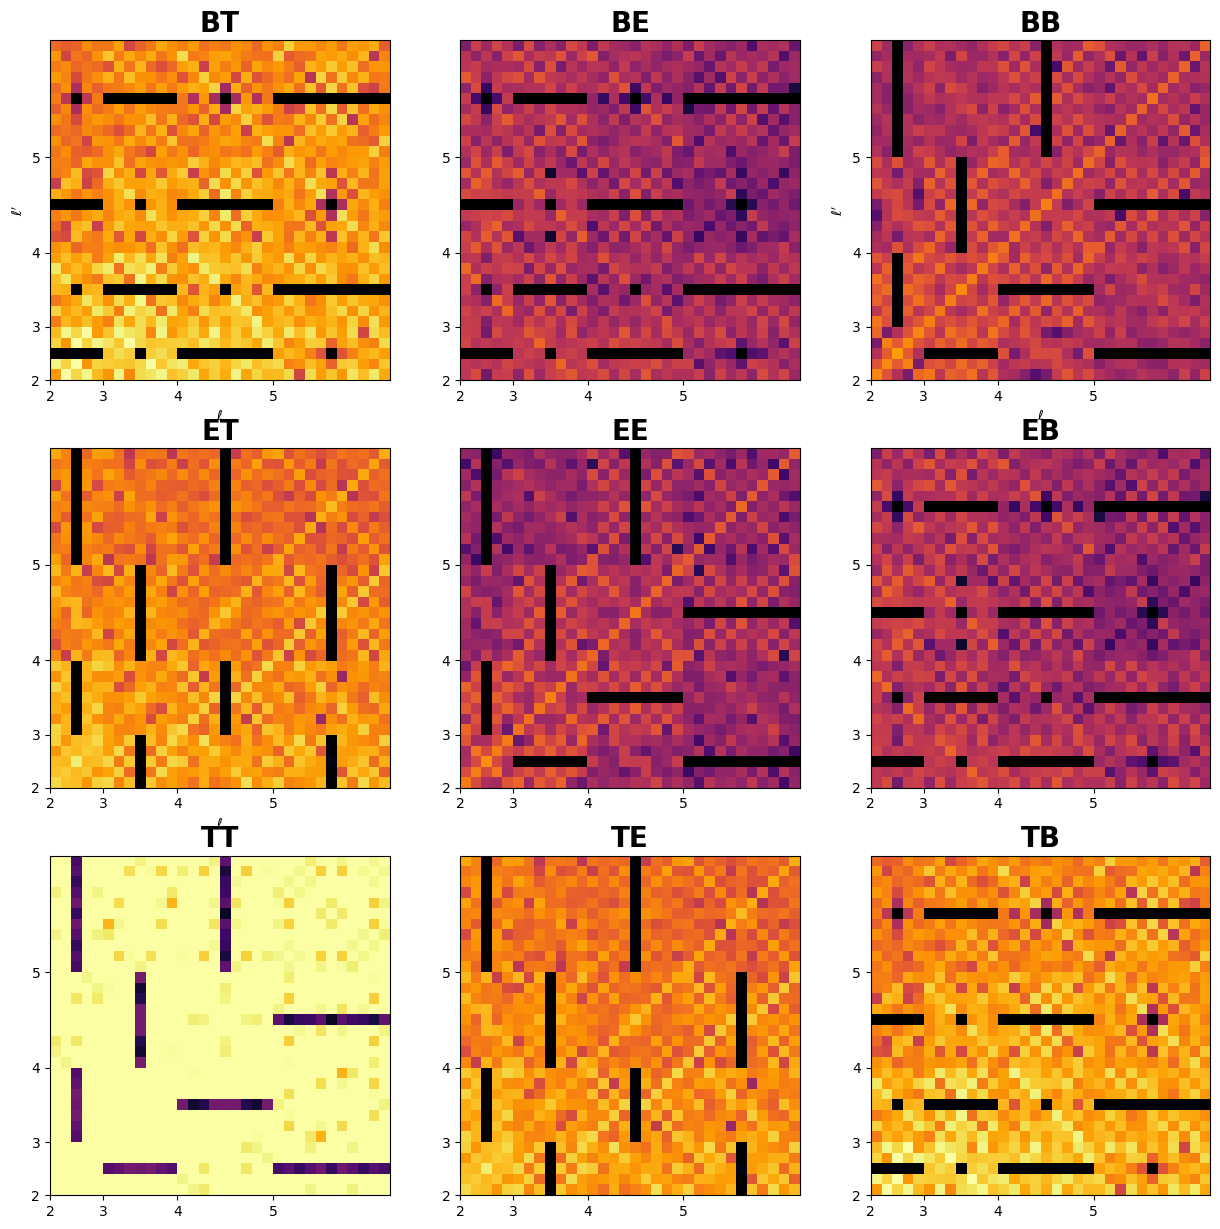

In [5]:
fig, ax = plt.subplots(3,3, figsize=(15,15))
do_cov_sub_plot(ax[0,0], normalize=True, title = 'BT',  ax_index=0, C_order=c_ell_left[5], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[0,1], normalize=True, title = 'BE', ax_index=1, C_order=c_ell_left[4], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[0,2], normalize=True, title = 'BB', ax_index=2, C_order=c_ell_left[2], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[1,0], normalize=True, title = 'ET', ax_index=3, C_order=c_ell_left[3], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[1,1], normalize=True, title = 'EE', ax_index=4, C_order=c_ell_left[1], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[1,2], normalize=True, title = 'EB', ax_index=5, C_order=c_ell_left[4], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[2,0], normalize=True, title = 'TT', ax_index=6, C_order=c_ell_left[0], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[2,1], normalize=True, title = 'TE', ax_index=7, C_order=c_ell_left[3], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[2,2], normalize=True, title = 'TB', ax_index=8, C_order=c_ell_left[5], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))

In [6]:
l_max = 5
L_circle = 0.73321

c_ell_right = run_topology_ricardo(topology = 'E7', LAx = L_circle, LAy = 0, L1y = 1.4, L2x = 0.7, L2z = 1, 
             l_max = l_max, x0= np.array([-0.1, 0.34, 0.0], dtype=np.float64), 
             l_range = np.array([[2,l_max]]), lp_range = np.array([[2,l_max]]))

Running - E7 l_max=5_LAx_20273_LAy_0_L1y_38709_L2x_19354_L2z_27649_x_-0.10_y_0.34_z_0.00
Running {'topology': 'E7', 'LAx': 0.73321, 'LAy': 0, 'L1y': 1.4, 'L2x': 0.7, 'L2z': 1, 'x0': array([-0.1 ,  0.34,  0.  ]), 'c_l_accuracy': 0.99, 'l_max': 5, 'l_min': 2, 'node': 1}
Shape of transfer function from CAMB: (3, 599, 6454)

Finding k_max as a function of ell


100%|██████████| 4/4 [00:00<00:00, 22.70it/s]

Done. k_max for ell_max = 0.01102416508743576


Intervals: 
 1 supspace - [0, 10634] 
 2 subspace - [10634, 970463]
Time to get list of k, phi, theta: 20.820831060409546 seconds
Getting repeated theta and k elements
Ratio of unique theta: 0.4208506661253443
Ratio of unique |k|: 0.07509817478873486
Time to get unique k and theta: 0.16930818557739258 seconds

Getting transfer functions


100%|██████████| 72880/72880 [00:02<00:00, 33087.13it/s]


...

Size of transfer function: 3.34 MB. 


Getting transfer functions


100%|██████████| 72880/72880 [00:03<00:00, 23376.78it/s]


Size of transfer function: 3.34 MB. 


Getting Wigner_d matrices!


100%|██████████| 408420/408420 [00:13<00:00, 30539.68it/s] 


The Wigner_d metrices array is 112.18 MB 


**************
Done with all preprocessing
**************

Time to pre-process with l_max=5 and accuracy=0.99: 85.02308917045593 seconds

Calculating covariance matrix
Size of integrand: 120.1 MB.
Time to get Correlation functions: 0:0:43


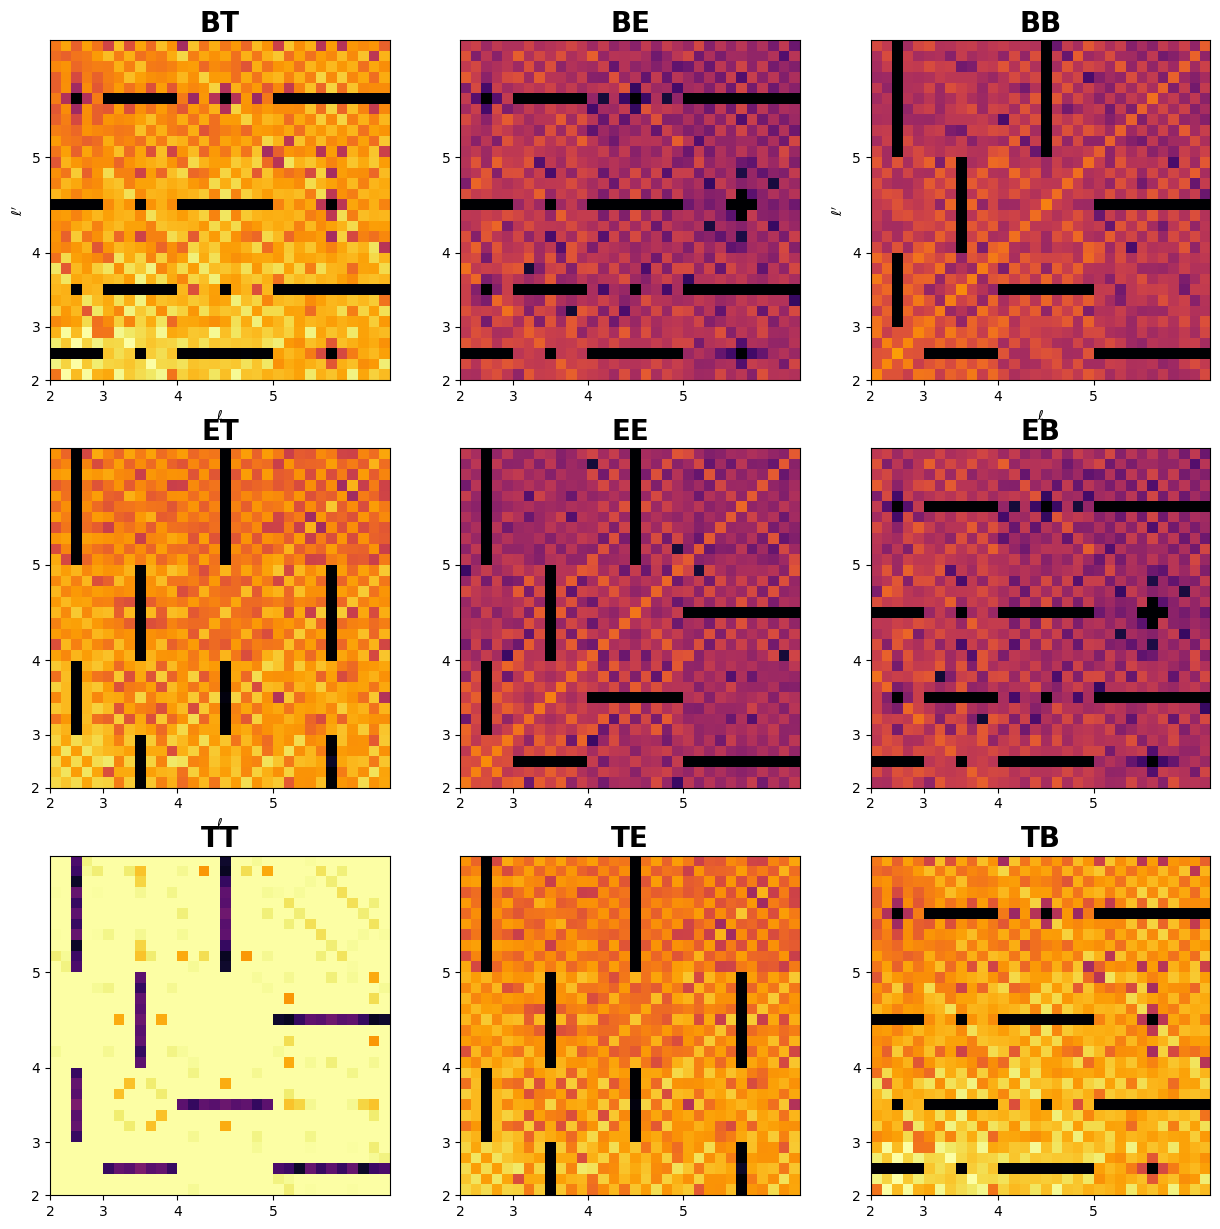

In [7]:
fig, ax = plt.subplots(3,3, figsize=(15,15))
do_cov_sub_plot(ax[0,0], normalize=True, title = 'BT',  ax_index=0, C_order=c_ell_right[5], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[0,1], normalize=True, title = 'BE', ax_index=1, C_order=c_ell_right[4], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[0,2], normalize=True, title = 'BB', ax_index=2, C_order=c_ell_right[2], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[1,0], normalize=True, title = 'ET', ax_index=3, C_order=c_ell_right[3], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[1,1], normalize=True, title = 'EE', ax_index=4, C_order=c_ell_right[1], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[1,2], normalize=True, title = 'EB', ax_index=5, C_order=c_ell_right[4], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[2,0], normalize=True, title = 'TT', ax_index=6, C_order=c_ell_right[0], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[2,1], normalize=True, title = 'TE', ax_index=7, C_order=c_ell_right[3], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[2,2], normalize=True, title = 'TB', ax_index=8, C_order=c_ell_right[5], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))

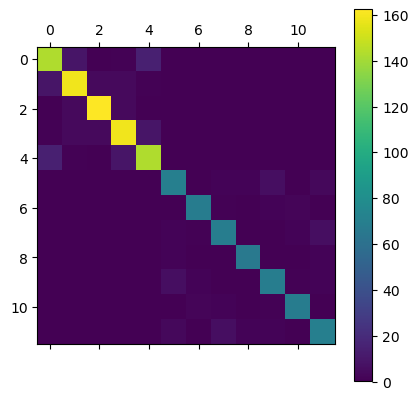

In [ ]:
plt.matshow(np.abs(c_ell[0]))
plt.colorbar()

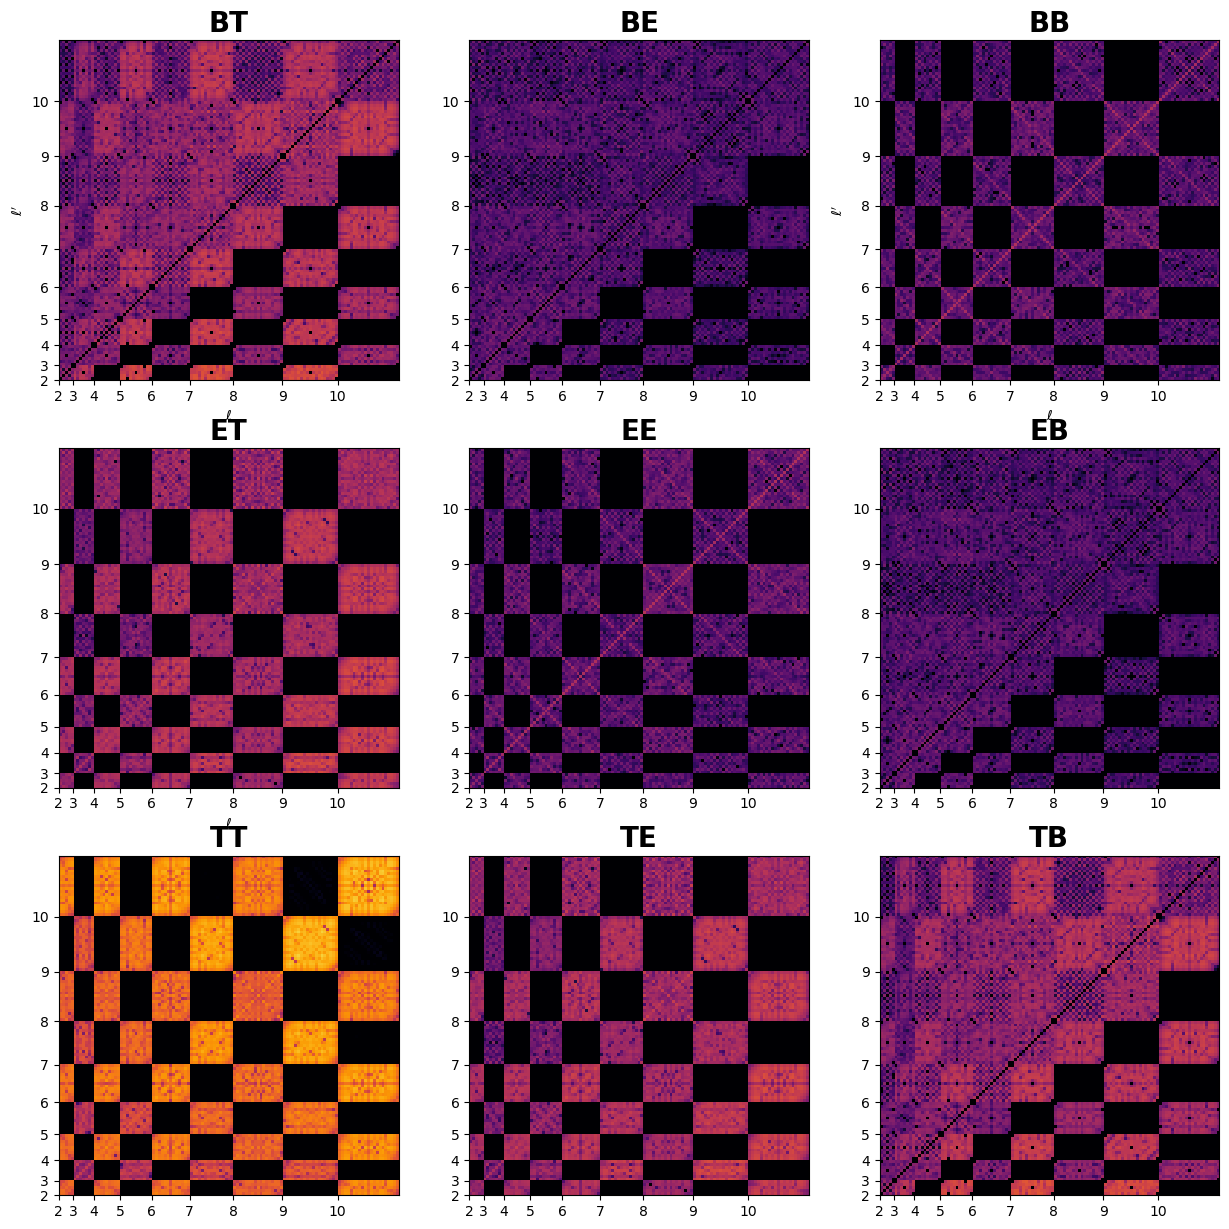

In [3]:
fig, ax = plt.subplots(3,3, figsize=(15,15))
do_cov_sub_plot(ax[0,0], normalize=True, title = 'BT',  ax_index=0, C_order=np.abs(c_ell[5]), ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[0,1], normalize=True, title = 'BE', ax_index=1, C_order=c_ell[4], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[0,2], normalize=True, title = 'BB', ax_index=2, C_order=c_ell[2], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[1,0], normalize=True, title = 'ET', ax_index=3, C_order=c_ell[3], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[1,1], normalize=True, title = 'EE', ax_index=4, C_order=c_ell[1], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[1,2], normalize=True, title = 'EB', ax_index=5, C_order=c_ell[4], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[2,0], normalize=True, title = 'TT', ax_index=6, C_order=c_ell[0], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[2,1], normalize=True, title = 'TE', ax_index=7, C_order=c_ell[3], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[2,2], normalize=True, title = 'TB', ax_index=8, C_order=c_ell[5], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))

In [5]:
l_max = 10
#L_circle = 0.73321

c_ell_amir = run_topology_amir(topology = 'E7', LAx = 0.1, LAy = 0.1, L1y = 0.1, L2x = 0.1, L2z = 0.1, 
             l_max = l_max, x0= np.array([0.0, 0.0, 0.0], dtype=np.float64), 
             l_range = np.array([[2,l_max]]), lp_range = np.array([[2,l_max]]))

Running - E7 l_max=10_LAx_2764_LAy_2764_L1y_2764_L2x_2764_L2z_2764_x_0.00_y_0.00_z_0.00
Running {'topology': 'E7', 'LAx': 0.1, 'LAy': 0.1, 'L1y': 0.1, 'L2x': 0.1, 'L2z': 0.1, 'x0': array([0., 0., 0.]), 'c_l_accuracy': 0.99, 'l_max': 10, 'l_min': 2, 'node': 1}


KeyboardInterrupt: 

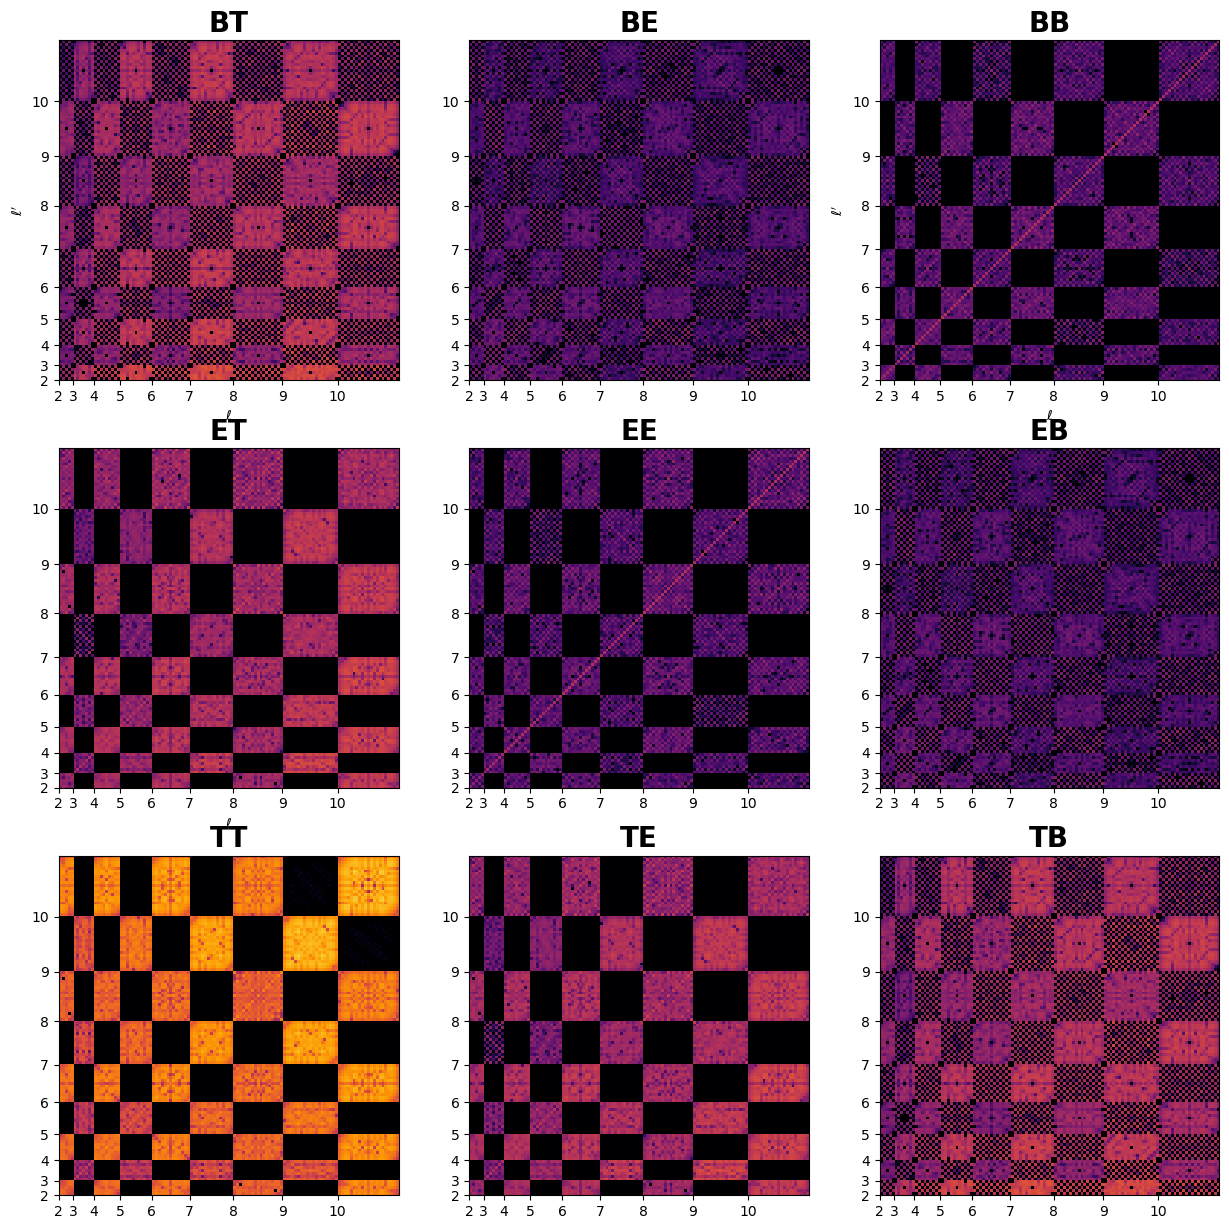

In [ ]:
fig, ax = plt.subplots(3,3, figsize=(15,15))
do_cov_sub_plot(ax[0,0], normalize=True, title = 'BT',  ax_index=0, C_order=c_ell_amir[5], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[0,1], normalize=True, title = 'BE', ax_index=1, C_order=c_ell_amir[4], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[0,2], normalize=True, title = 'BB', ax_index=2, C_order=c_ell_amir[2], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[1,0], normalize=True, title = 'ET', ax_index=3, C_order=c_ell_amir[3], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[1,1], normalize=True, title = 'EE', ax_index=4, C_order=c_ell_amir[1], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[1,2], normalize=True, title = 'EB', ax_index=5, C_order=c_ell_amir[4], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[2,0], normalize=True, title = 'TT', ax_index=6, C_order=c_ell_amir[0], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[2,1], normalize=True, title = 'TE', ax_index=7, C_order=c_ell_amir[3], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))
do_cov_sub_plot(ax[2,2], normalize=True, title = 'TB', ax_index=8, C_order=c_ell_amir[5], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))

In [ ]:
c_ell[0]

array([[ 2.09247669e-03+0.00000000e+00j, -1.67283969e-03+1.02431889e-19j,
         9.64332183e-04-1.18096629e-19j, ...,
        -1.42626144e-03+8.73333093e-19j,  4.73539754e-04-3.18955353e-19j,
         9.32168160e-06+5.49152886e-21j],
       [-1.67283969e-03-1.02431889e-19j,  1.57474786e-03+0.00000000e+00j,
        -5.85371970e-04+3.58436936e-20j, ...,
        -5.22364292e-04+2.87870297e-19j,  7.41871281e-04-4.54265091e-19j,
        -1.27313754e-04+1.41795129e-19j],
       [ 9.64332183e-04+1.18096629e-19j, -5.85371970e-04-3.58436936e-20j,
         9.19950997e-04+0.00000000e+00j, ...,
        -4.80259480e-03+2.35259270e-18j,  2.55184759e-03-1.40630017e-18j,
        -3.88151864e-04+3.19059329e-19j],
       ...,
       [-1.42626144e-03-8.73333093e-19j, -5.22364292e-04-2.87870297e-19j,
        -4.80259480e-03-2.35259270e-18j, ...,
         5.24841620e-02+0.00000000e+00j, -2.93012771e-02+1.79418549e-18j,
         9.10380006e-03+1.34700420e-10j],
       [ 4.73539754e-04+3.18955353e-19j,  7.

In [ ]:
c_ell_amir[0]

array([[ 0.00313594+0.00000000e+00j, -0.00236575+1.45826560e-19j,
         0.00114822-1.66981432e-19j, ..., -0.00199735+1.23361287e-18j,
         0.00066969-4.53021730e-19j,  0.00033703+2.70908203e-21j],
       [-0.00236575-1.45826560e-19j,  0.00268721+0.00000000e+00j,
        -0.00082784+4.95766434e-20j, ..., -0.00073873+4.05889083e-19j,
         0.00069003-6.39734109e-19j, -0.00029949+1.99176250e-19j],
       [ 0.00114822+1.67046276e-19j, -0.00082784-4.95766434e-20j,
         0.00192088+0.00000000e+00j, ..., -0.00685553+3.32672361e-18j,
         0.00360886-1.98874654e-18j, -0.00136568+4.51776626e-19j],
       ...,
       [-0.00199735-1.23361287e-18j, -0.00073873-4.05889083e-19j,
        -0.00685553-3.32672361e-18j, ...,  0.07459745+0.00000000e+00j,
        -0.04143826+2.54157310e-18j,  0.0127818 -1.56987227e-18j],
       [ 0.00066969+4.53021730e-19j,  0.00069003+6.39734109e-19j,
         0.00360886+1.98874654e-18j, ..., -0.04143826-2.54157310e-18j,
         0.02470432+0.00000000e+00j

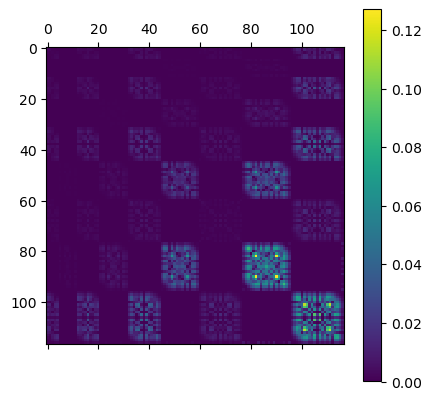

In [ ]:
plt.matshow(np.abs(c_ell[0]))
plt.colorbar()

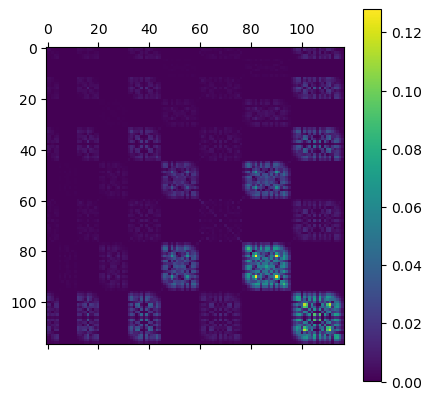

In [ ]:
plt.matshow(np.abs(c_ell_amir[0]))
plt.colorbar()

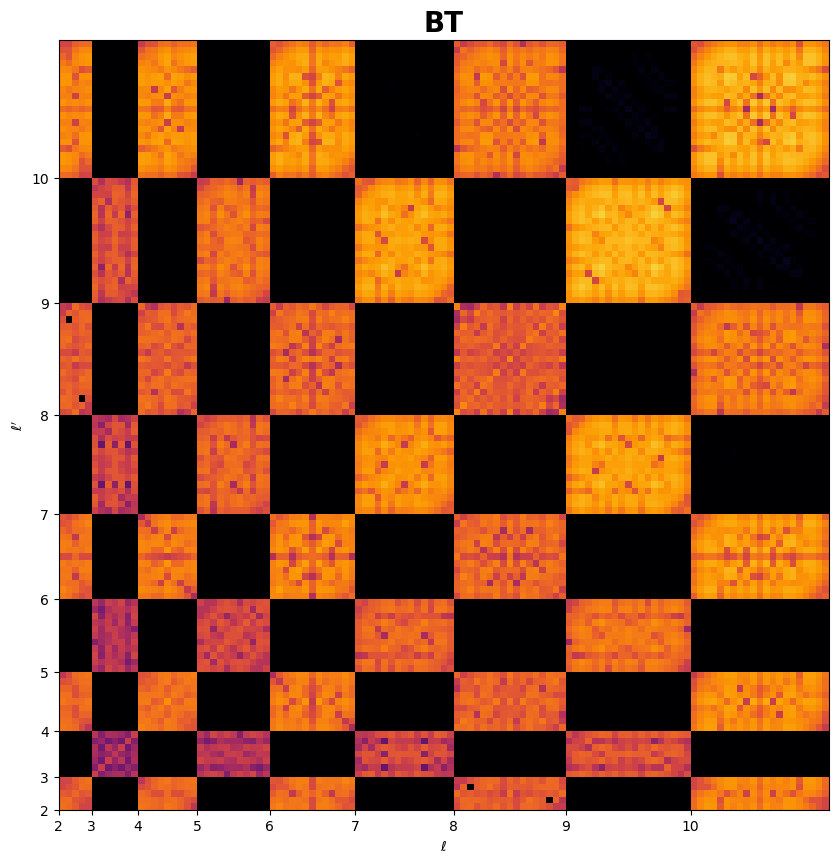

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(10,10))
do_cov_sub_plot(ax, normalize=True, title = 'BT',  ax_index=0, C_order=c_ell[0], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))

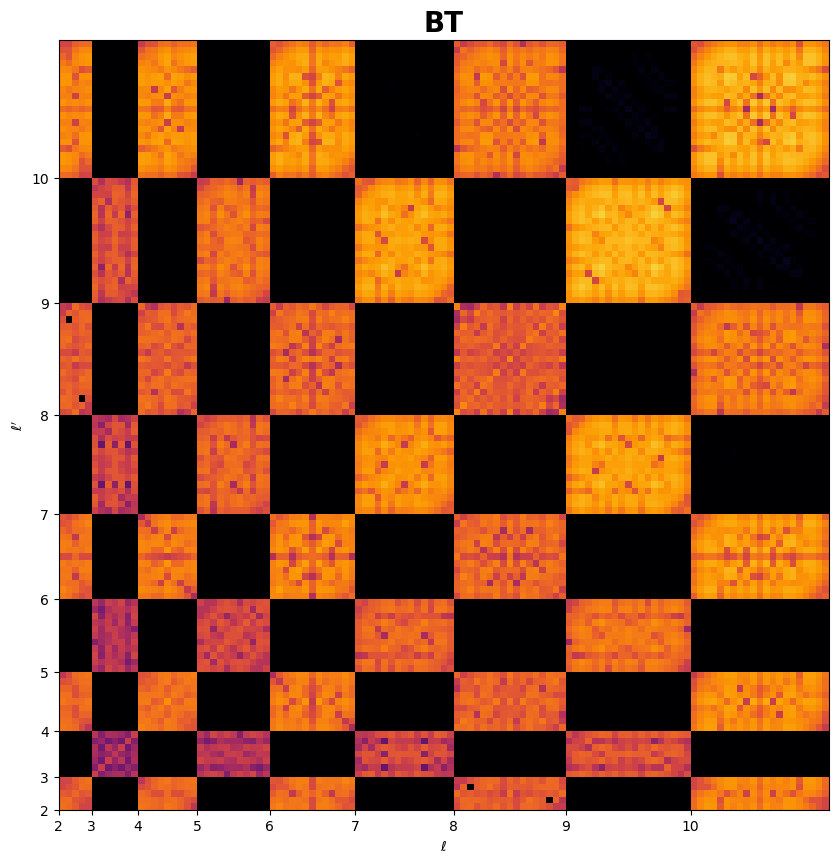

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(10,10))
do_cov_sub_plot(ax, normalize=True, title = 'BT',  ax_index=0, C_order=c_ell_amir[0], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))

In [ ]:
l_max = 9
#L_circle = 0.73321

c_ell = run_topology_ricardo(topology = 'E7', LAx = 0.1, LAy = 0.1, L1y = 0.1, L2x = 0.1, L2z = 0.1, 
             l_max = l_max, x0= np.array([0.0, 0.0, 0.0], dtype=np.float64), 
             l_range = np.array([[2,l_max]]), lp_range = np.array([[2,l_max]]))

Running - E7 l_max=9_LAx_2764_LAy_2764_L1y_2764_L2x_2764_L2z_2764_x_0.00_y_0.00_z_0.00
Running {'topology': 'E7', 'LAx': 0.1, 'LAy': 0.1, 'L1y': 0.1, 'L2x': 0.1, 'L2z': 0.1, 'x0': array([0., 0., 0.]), 'c_l_accuracy': 0.99, 'l_max': 9, 'l_min': 2, 'node': 1}
Making run folder: runs/E7_LAx_0.10_LAy_0.10_L1y_0.10_L2x_0.10_L2z_0.10_x_0.00_y_0.00_z_0.00_l_max_9/
Shape of transfer function from CAMB: (3, 599, 6454)

Finding k_max as a function of ell


100%|██████████| 8/8 [00:00<00:00, 25.86it/s]


Done. k_max for ell_max = 0.01674955334307199
Intervals: 
 1 supspace - [0, 306] 
 2 subspace - [306, 3205]
Time to get list of k, phi, theta: 0.16423988342285156 seconds
Getting repeated theta and k elements
Ratio of unique theta: 0.15569422776911077
Ratio of unique |k|: 0.031513260530421215
Time to get unique k and theta: 0.001035928726196289 seconds

Getting transfer functions


100%|██████████| 101/101 [00:01<00:00, 51.49it/s]

Size of transfer function: 0.01 MB. 



...

Size of transfer function: 0.01 MB. 




Getting Wigner_d matrices!


100%|██████████| 499/499 [00:01<00:00, 482.62it/s]

The Wigner_d metrices array is 0.4 MB 


**************
Done with all preprocessing
**************

Time to pre-process with l_max=9 and accuracy=0.99: 36.57199215888977 seconds

Calculating covariance matrix
Size of integrand: 0.46 MB.


Time to get Correlation functions: 0:0:9


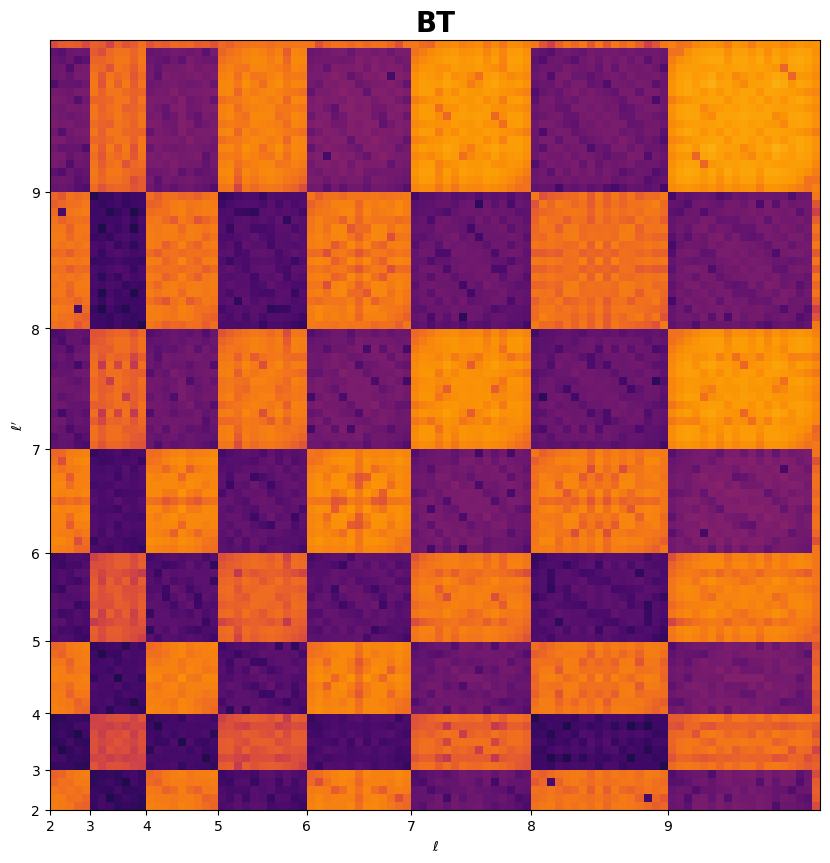

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(10,10))
do_cov_sub_plot(ax, normalize=False, title = 'BT',  ax_index=0, C_order=c_ell[0], ell_range = np.array([2,l_max]), ell_p_range = np.array([2,l_max]))

In [ ]:
for ell in range(2,5):
    for m in range(-ell, ell+1):
        print(ell * (ell+1) + m - 4)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20


In [5]:
import healpy as hp
import numpy as np

In [3]:
def cart2spherical(xyz):
    # Calculates spherical coordinates from cartesian coordinates
    xy = xyz[0]**2 + xyz[1]**2

    # phi
    phi = np.arctan2(xyz[1], xyz[0])
    # theta
    theta = np.arctan2(np.sqrt(xy), xyz[2])
    
    return phi, theta

In [9]:
phi_null, theta_null = cart2spherical([1,2,3])
phi_null_minus, theta_null_minus = cart2spherical([-1,-2,-3])

In [11]:
phi_null, theta_null, phi_null_minus, theta_null_minus

(np.float64(1.1071487177940904),
 np.float64(0.6405223126794246),
 np.float64(-2.0344439357957027),
 np.float64(2.5010703409103687))